# Clinical NLP over Italian Hospital Records — A Neuro-Symbolic Pipeline

*NLP4DH exam project.* An end-to-end pipeline over 857 pseudonymized Italian discharge records, built to demonstrate a broad range of course techniques: **regex extraction**, **dense retrieval / RAG**, **zero-shot NER (GLiNER)**, **dependency parsing**, **symbolic vs. neural context classification**, **entity linking**, a **symbolic alert engine**, **neuro-symbolic tool-calling (Ollama)**, and a **knowledge graph with SPARQL**.

Each section opens by naming the course concept it demonstrates (often via the **Kautz taxonomy** of neuro-symbolic systems). The goal is *breadth, correctness, and clarity of exposition* — not state-of-the-art accuracy.

> **Notebook structure**
> 0. EDA & responsible-data-handling note
> 1. Regex extraction — discharge therapy *(pure symbolic baseline)*
> 2. Dense-retrieval extraction — ingress therapy *(RAG retrieval stage)*
> 3. GLiNER entity extraction — anamnesis *(Kautz Type 1)*
> 4. Context classification — NegEx / NLI / System-1+2 *(Kautz Type 2, Kahneman)*
> 5. Entity linking — ATC & ICD-9-CM
> 6. Alert engine *(symbolic, deterministic)*
> 7. Ollama + tool calling *(Kautz Type 6)*
> 8. Knowledge graph, SPARQL & temporal timeline *(Discourse level)*
> 9. Gold annotation & evaluation (50 patients)
> 10. Discussion & limitations


## Section 0 — Exploratory Data Analysis & Responsible Data Handling

**Goal.** Before building any NLP component, we look at what the data actually contains: how many
patients and reports there are, how long the free text is per report type, and — crucially — the
*edge cases* that every downstream step will have to survive (empty therapies, combination drugs,
non-drug lines such as oxygen / NIV / CPAP).

**Course mapping.** This is the standard *data-understanding* phase. It is not itself an NLP
technique, but it drives every design decision below (e.g. which regex branches Step 1 needs, and
which lines Step 2 must filter out before entity matching).

### ⚠️ Responsible handling of clinical data
This dataset consists of **pseudonymized clinical records** used here for a **university exam,
educational purpose only**. Accordingly, throughout this notebook we:

- make **no attempt at re-identification** of any patient, and treat `encOid` as an opaque key;
- show only **short, representative excerpts** needed to illustrate a technique, never bulk dumps of
  raw records, and do not publish extensive raw text outside this notebook;
- keep all processing **local** (no clinical text is sent to third-party cloud APIs — the only LLM
  used, in Step 7, is a *local* Ollama model running on this machine).

In [1]:
# --- Global setup: imports, paths, reproducibility -------------------------------------------
# Everything downstream reuses the paths and the SEED defined here.
import json, re, random
from pathlib import Path
import numpy as np
import pandas as pd

# Resolve the project root whether the notebook is run from ./ or ./notebooks/
# Quiet the transformers/HF info logs and progress bars so the saved output stays clean.
from transformers.utils import logging as _hf_logging
_hf_logging.set_verbosity_error(); _hf_logging.disable_progress_bar()
try:
    from huggingface_hub.utils import disable_progress_bars as _disable_hf_bars
    _disable_hf_bars()
except Exception:
    pass

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA      = PROJECT_ROOT / "data"
EXTERNAL  = DATA / "external"          # pre-downloaded knowledge resources (AIFA, DDInter, ...)
OUTPUTS   = PROJECT_ROOT / "outputs"   # cached intermediate dataframes (so re-runs are cheap)
ANNOT     = DATA / "annotations"       # gold annotations (Step 9)
OUTPUTS.mkdir(exist_ok=True)
ANNOT.mkdir(exist_ok=True)

SEED = 42                              # single seed used everywhere we sample
random.seed(SEED); np.random.seed(SEED)

pd.set_option("display.max_colwidth", 90)

# Load the raw dataset: a list of 857 patients, each with exactly three reports.
with open(DATA / "pazienti_con_terapia_uscita_testuale.json", encoding="utf-8") as f:
    patients = json.load(f)

# The three report types every patient has. We keep the Italian names as-is (they are data).
T_ANAMNESI  = "Anamnesi"
T_INGRESSO  = "Terapia medica all'ingresso"
T_DIMISSIONE = "Terapia alla Dimissione"

def report_text(patient, tipo):
    "Return the free text of a given report type for a patient ('' if missing)."
    for r in patient["referti"]:
        if r["tipo"] == tipo:
            return r["testo"] or ""
    return ""

def report_date(patient, tipo):
    "Return the raw date string of a given report type ('' if missing)."
    for r in patient["referti"]:
        if r["tipo"] == tipo:
            return r.get("data") or ""
    return ""

print(f"Loaded {len(patients)} patients from {DATA.name}/")
print("Project directories initialized.")

Loaded 857 patients from data/
Project directories initialized.


In [2]:
# --- Dataset shape: counts + per-report-type text-length statistics --------------------------
rows = []
for p in patients:
    for r in p["referti"]:
        rows.append({"tipo": r["tipo"], "len_chars": len(r["testo"] or "")})
reports_df = pd.DataFrame(rows)

n_patients = len(patients)
n_exactly3 = sum(len(p["referti"]) == 3 for p in patients)
print(f"patients: {n_patients} | patients with exactly 3 reports: {n_exactly3}")

length_stats = (reports_df.groupby("tipo")["len_chars"]
                .agg(["count", "min", "median", "mean", "max"])
                .round(0).astype(int))
length_stats

patients: 857 | patients with exactly 3 reports: 857


,count,min,median,mean,max
tipo,,,,,
Anamnesi,857,222,1693,2239,15968
Terapia alla Dimissione,857,15,649,679,2281
Terapia medica all'ingresso,857,4,284,318,1899


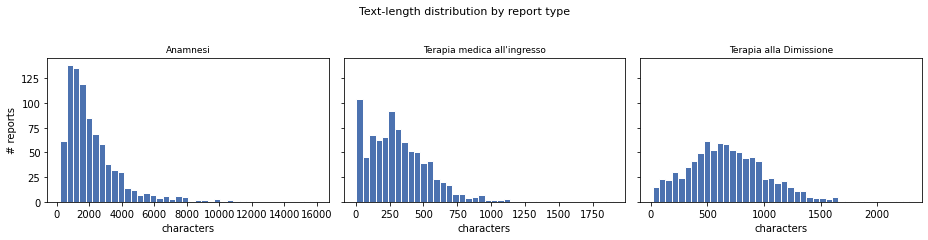

In [3]:
# --- Text-length distribution per report type (log x, since Anamnesi is very skewed) ---------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, tipo in zip(axes, [T_ANAMNESI, T_INGRESSO, T_DIMISSIONE]):
    vals = reports_df.loc[reports_df.tipo == tipo, "len_chars"]
    ax.hist(vals, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(tipo, fontsize=9)
    ax.set_xlabel("characters")
axes[0].set_ylabel("# reports")
fig.suptitle("Text-length distribution by report type", y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

In [4]:
# --- Representative examples, including the edge cases downstream steps must handle -----------
def show(title, text, width=350):
    print(f"### {title}\n{text[:width]}{'…' if len(text) > width else ''}\n")

# A "normal" structured discharge line (near-template) + a combination drug (Clopidogrel/ASA):
show("Terapia alla Dimissione — structured template + combination drug",
     report_text(patients[0], T_DIMISSIONE))

# A "normal" ingress line (semi-structured 'Nome: dose forma /die (ore N)'):
show("Terapia medica all'ingresso — semi-structured", report_text(patients[0], T_INGRESSO))

# Edge case 1: empty home therapy.
ex_empty = next(p for p in patients if "essuna terapia" in report_text(p, T_INGRESSO))
show("EDGE — empty home therapy", report_text(ex_empty, T_INGRESSO))

# Edge case 2: non-drug therapy line (oxygen / NIV / CPAP) mixed with drugs — must be filtered.
ex_o2 = next(p for p in patients if re.search(r"Ossigeno|NIV|CPAP", report_text(p, T_INGRESSO)))
show("EDGE — non-drug lines (O2/NIV/CPAP) among drugs", report_text(ex_o2, T_INGRESSO))

# Edge case 3: bare description with no dose/structure.
ex_bare = next(p for p in patients
               if not re.search(r"\d", report_text(p, T_INGRESSO))
               and "essuna" not in report_text(p, T_INGRESSO)
               and len(report_text(p, T_INGRESSO)) > 10)
show("EDGE — bare free-text, no doses", report_text(ex_bare, T_INGRESSO))

### Terapia alla Dimissione — structured template + combination drug
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300 mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI (ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin cp.riv. 75 mg): da assumere 75/100 mg (ore 19)" "Panto…

### Terapia medica all'ingresso — semi-structured
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ; Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

### EDGE — empty home therapy
Nessuna terapia domiciliare.

### EDGE — non-drug lines (O2/NIV/CPAP) among drugs
Rosumibe: 10/10 mg cpr. /die (ore 22) ; Coversyl: 20 mg cp.riv. /die (ore 8) ; Norvasc: 5 mg cpr. divisibili /die (ore 20) ; Clopidogrel zen: 7

**What the EDA tells us (and how it shapes the pipeline):**

| Observation | Consequence for the pipeline |
|---|---|
| All 857 patients have exactly the 3 expected report types | We can retrieve reports reliably by type without missing-report handling. |
| *Terapia alla Dimissione* follows a near-fixed template `Principio (Nome forma dosaggio): da assumere …` | **Step 1** can extract it with regular expressions as a **pure symbolic baseline, outside the neuro-symbolic Kautz architectures**. |
| *Terapia medica all'ingresso* is short and heterogeneous — semi-structured, bare lists, empty, or non-drug | **Step 2** needs a *soft* matcher (dense retrieval) and a pre-filter for O2/NIV/CPAP. |
| *Anamnesi* is long, narrative Italian prose | **Step 3–4** need NER + context (negation/family/temporal) over real syntax. |
| Combination drugs appear as `Clopidogrel/acido acetilsalicilico` | Step 1 must **split active ingredients on `/`**. |

These edge cases (empty / non-drug / bare / combination) are exactly the ones we will keep re-testing
against as we build each component.

## Section 1 — Structured extraction from *Terapia alla Dimissione* (regex)

**Course mapping — a purely symbolic component.** The discharge therapy follows a near-fixed
template, so extraction is done with named-group regular expressions and has *no neural component at
all*. Strictly, Kautz's Type 1 (*Symbolic Neuro Symbolic*) still contains a neural network (symbols
in, symbols out, neural in the middle) — so this stage is really a **pure symbolic baseline, outside the neuro-symbolic Kautz architectures** —
not a true Type 1. We include it as the symbolic baseline of the pipeline, and because its deterministic
output is a useful reference against which the neural retrieval of Step 2 can be compared.

The template is:
```
"Principio attivo (Nome commerciale forma dosaggio): <body>"
```
where `<body>` is usually `da assumere <dose> <unit> (ore N)[, <dose> (ore N) …] [free-text notes]`.
We parse it in three didactic stages — **header**, **commercial part**, **body** — rather than with
one monolithic regex, so each piece is easy to read and test.

In [5]:
import re

# ---- Vocabularies / building-block patterns -------------------------------------------------
# Pharmaceutical-form lead tokens: the commercial part is "<Brand> <forma> <dose><unit>", and the
# forma always begins with one of these abbreviations. We split the brand from the forma there.
FORMA_LEAD = re.compile(r'\b(cp|cpr|cps|compress|cerott|soluz|sosp|comp|bust|gtt|fial|fl|'
                        r'capsul|ovul|crema|pomata|collirio|spray|scir|granul|polvere|nebuliz)', re.I)
# Trailing strength inside the parenthesis, e.g. "... 5 mg", "... 7000 UI", "... 10 mg/d".
DOSE_TAIL  = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)?)\s*(mg/d|mg|mcg|g|UI|ml|%)\s*$', re.I)
# Non-drug therapy lines (oxygen / ventilation) that must NOT enter the drug table.
NONDRUG    = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil)', re.I)
# A numeric dose that immediately governs an "(ore N)" administration-time group.
DOSE_ORA   = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)?)\s*(mg|mcg|g|UI|ml|gtt)?'
                        r'[^()]*?\(ore\s*([^)]+)\)', re.I)
# Header: "<principio attivo> (<commercial>)?: <body>"
HEADER     = re.compile(r'^\s*(?P<pa>[^(:]+?)\s*(?:\((?P<comm>[^)]*)\))?\s*:\s*(?P<body>.*)$', re.S)


def to_float(s):
    """Italian decimal comma -> float. Combination doses ('75/100') keep the first component."""
    if s is None:
        return None
    s = s.split("/")[0].replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return None


def parse_commercial(comm):
    """'Atorvastatina sa cp.riv. 80 mg' -> (nome_commerciale, forma, dosaggio_unitario, unit)."""
    dosaggio = unit = None
    rest = comm
    m = DOSE_TAIL.search(comm)
    if m:
        dosaggio, unit = m.group(1), m.group(2)
        rest = comm[:m.start()].strip()
    fm = FORMA_LEAD.search(rest)
    if fm:
        nome, forma = rest[:fm.start()].strip(), rest[fm.start():].strip()
    else:
        nome, forma = rest, None
    return (nome or None), forma, dosaggio, unit


def count_administration_times(ore_text):
    """Count clock times inside an '(ore ...)' group: '09:30'->1, '8-20'->2, '8, 14, 20'->3."""
    return len(re.findall(r"(?<!\d)(?:[01]?\d|2[0-3])(?:[:.][0-5]\d)?(?!\d)", ore_text))


def parse_body(body):
    """Extract (dose, ora) pairs, a per-day frequency, and the residual free-text note."""
    pairs = [(to_float(dose), re.sub(r'\s+', '', ora)) for dose, _u, ora in DOSE_ORA.findall(body)]
    # frequenza/die = number of administration TIMES in the "(ore ...)" groups; count clock times,
    # not digit runs ("(ore 09:30)" is 1, "(ore 8-20)" is 2, "(ore 8, 14, 20)" is 3).
    freq = sum(count_administration_times(ore) for ore in re.findall(r'\(ore\s*([^)]+)\)', body))
    # note = whatever free text is left once dose/(ore ...) chunks are removed
    note = re.sub(r'^\s*da assumere\s*', '', body)
    note = DOSE_ORA.sub(' ', note)
    note = re.sub(r'\(ore[^)]*\)', ' ', note)
    note = re.sub(r'\s+', ' ', note).strip(' ,.;')
    return pairs, (freq or None), (note or None)


def parse_discharge_entry(entry):
    """Parse one quoted drug entry into a dict, or None if it is a non-drug/undecodable line."""
    entry = entry.strip()
    if not entry or NONDRUG.search(entry.split("(")[0]):
        return None
    m = HEADER.match(entry)
    if not m:
        return None
    pa_raw = m.group("pa").strip()
    if NONDRUG.search(pa_raw):
        return None
    nome, forma, dos_u, unit = parse_commercial(m.group("comm")) if m.group("comm") else (None, None, None, None)
    pairs, freq, note = parse_body(m.group("body"))
    # prescription status: currently-suspended (past participle 'sospeso/a'), PRN ('al bisogno'),
    # else active. NB 'poi sospendere' is a *planned* future stop -> still active now.
    _body = m.group("body").lower()
    status = ("suspended" if re.search(r"\bsospes[oaei]\b", _body)
              else "prn" if "al bisogno" in _body else "active")
    return dict(
        principio_attivo=[x.strip() for x in pa_raw.split("/") if x.strip()],  # split combination drugs on '/'
        nome_commerciale=nome, forma=forma,
        dosaggio_unitario=to_float(dos_u), unit=unit,
        dose_ora=pairs, frequenza_die=freq, note=note, status=status,
    )

In [6]:
# ---- Run the parser over all patients -> one tidy row per drug per patient ------------------
def is_empty_discharge(text):
    """Empty only if the report states a *global* absence of therapy. A report that contains quoted
    drug entries is never empty, even if it also mentions 'nessuna' somewhere (e.g. a report ending
    '... al momento nessuna Ossigeno 2 lt/min' that still lists five real prescriptions)."""
    t = text.strip().lower()
    if not t:
        return True
    if re.search(r'"[^"]+"', text):            # has quoted drug entries -> not empty
        return False
    return bool(re.search(r'nessun|non assume|nulla|assente', t))

discharge_rows = []
n_patients_with_therapy = n_nondrug = 0
for p in patients:
    text = report_text(p, T_DIMISSIONE)
    if is_empty_discharge(text):
        continue
    n_patients_with_therapy += 1
    entries = re.findall(r'"([^"]*)"', text) or [text]   # entries are quoted; fall back to whole text
    for e in entries:
        parsed = parse_discharge_entry(e)
        if parsed is None:
            if e.strip():
                n_nondrug += 1
            continue
        discharge_rows.append({"encOid": p["encOid"], **parsed})

discharge_df = pd.DataFrame(discharge_rows)

print(f"patients with a drug therapy : {n_patients_with_therapy}")
print(f"non-drug / undecodable lines : {n_nondrug}  (oxygen, NIV, 'secondo schema', ...)")
print(f"drug rows extracted          : {len(discharge_df)}")
print(f"combination drugs (>=2 PA)   : {(discharge_df.principio_attivo.map(len) > 1).sum()}")
print(f"rows without an explicit dose: {discharge_df.dose_ora.map(len).eq(0).sum()}")
discharge_df.head(8)

patients with a drug therapy : 852
non-drug / undecodable lines : 197  (oxygen, NIV, 'secondo schema', ...)
drug rows extracted          : 6259
combination drugs (>=2 PA)   : 695
rows without an explicit dose: 201


,encOid,principio_attivo,nome_commerciale,forma,dosaggio_unitario,unit,dose_ora,frequenza_die,note,status
0,10216091,[Acido folico],Folina,cps. molli,5.0,mg,"[(5.0, 15)]",1.0,None,active
1,10216091,[Tiamina],Benerva,cpr.gastr.,300.0,mg,"[(300.0, 15)]",1.0,None,active
2,10216091,[Colecalciferolo],Annova,cp.riv.,7000.0,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,mg,"[(75.0, 19)]",1.0,None,active
4,10216091,[Pantoprazolo],Pantoprazolo sand,cpr.gastr.,20.0,mg,"[(20.0, 8)]",1.0,None,active
5,10216091,[Atorvastatina],Atorvastatina sa,cp.riv.,80.0,mg,"[(80.0, 22)]",1.0,None,active
6,10216091,[Tamsulosina],Omnic,cps. rigide rm,0.4,mg,"[(0.4, 22)]",1.0,None,active
7,10175544,[Omeprazolo],Omeprazolo my,cps.,20.0,mg,"[(20.0, 8)]",1.0,None,active


In [7]:
# ---- Cache to disk so downstream sections need not recompute --------------------------------
# Parquet cannot store Python lists/tuples directly, so we JSON-encode the two structured columns.
import json
_cache = discharge_df.copy()
_cache["principio_attivo"] = _cache["principio_attivo"].map(json.dumps)
_cache["dose_ora"]         = _cache["dose_ora"].map(json.dumps)
_cache.to_parquet(OUTPUTS / "step1_discharge_drugs.parquet")
print("cached -> outputs/step1_discharge_drugs.parquet")

# Show a couple of illustrative rows: a combination drug and one carrying a free-text note.
discharge_df[discharge_df.note.notna() | (discharge_df.principio_attivo.map(len) > 1)].head(6)

cached -> outputs/step1_discharge_drugs.parquet


,encOid,principio_attivo,nome_commerciale,forma,dosaggio_unitario,unit,dose_ora,frequenza_die,note,status
2,10216091,[Colecalciferolo],Annova,cp.riv.,7000.0,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,mg,"[(75.0, 19)]",1.0,None,active
9,10175544,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,mg,"[(75.0, 20)]",1.0,None,active
11,10223315,"[Rosuvastatina, ezetimibe]",Rosumibe,cpr.,10.0,mg,"[(10.0, 22)]",1.0,None,active
12,10223315,"[Perindopril, amlodipina]",Reaptan,cp.riv.,10.0,mg,"[(10.0, 8)]",1.0,None,active
22,10231321,"[Vildagliptin, metformina]",Vildagliptin met te,cp.riv.,1000.0,mg,"[(1000.0, 8), (1000.0, 20)]",2.0,None,active


**Wrap-up.** Pure symbolic extraction turns 852 free-text discharge reports into ~6.2k structured
drug rows, correctly handling the edge cases identified in the EDA: **combination drugs** are split
into their active ingredients (`Clopidogrel/acido acetilsalicilico → [Clopidogrel, acido
acetilsalicilico]`), **non-drug lines** (oxygen/NIV/CPAP) are filtered out, and free-text **notes**
(`per 6 mesi, poi stop`, `a giorni alterni`, `come da schema domiciliare`, …) are preserved.

*Limitations (by design).* A minority of entries use count-based bodies (`1 cp`, `mezza cp x 2`)
rather than an explicit `da assumere <dose>`; for those the `dose_ora` numeric dose may be a tablet
count. This is acceptable because the field we rely on downstream — `principio_attivo` — is extracted
from the deterministic header, not the body. **This `discharge_df` is the reference against which the
neural retrieval of Step 2 will be scored.**

## Section 2 — Extraction from *Terapia medica all'ingresso* via dense retrieval

**Course mapping — the Retrieval stage of RAG (Guu et al.).** The classic RAG schema is
*retrieve relevant passages, then generate an answer conditioned on them*. Here we reuse **only the
retrieval half**, and repurpose it from question-answering to **entity normalization**: the "query"
is a messy drug mention from the free text, the "documents" are the entries of an official drug
dictionary, and we retrieve the closest one by dense-vector cosine similarity.

**Why not fuzzy string matching?** Levenshtein/RapidFuzz was *not* covered in the course, so we
deliberately avoid it. Dense retrieval is also genuinely better here: `Clopidogrel zen` →
`CLOPIDOGREL ZENTIVA` is easy for embeddings but hard for edit distance, and pure brands
(`Omnic` → tamsulosin) have *no* orthographic overlap with their active ingredient at all.

**Dictionary — AIFA (official, free).** We use the AIFA drug registry (*anagrafica farmaci*,
`aifa.gov.it/liste-dei-farmaci`), already downloaded under `data/external/aifa/`. Its
`medications.csv` gives 14,976 entries, each a `preferred_label` (active ingredient *or* brand) with
its ATC code(s). No hand-written dictionary is used.

In [8]:
from sentence_transformers import SentenceTransformer
import torch

# Single device switch, with a CPU fallback so the notebook is portable (slower on CPU).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NLI_DEVICE = 0 if DEVICE == "cuda" else -1

# ---- Load the AIFA dictionary and build a symbolic exact name->ATC map ----------------------
aifa = pd.read_csv(EXTERNAL / "aifa" / "normalized" / "medications.csv")
aifa = aifa[["preferred_label", "ATC"]].dropna().reset_index(drop=True)
aifa["atc1"] = aifa.ATC.str.split("|").str[0]          # first ATC (used only for the retrieval index)
DICT_LABELS = aifa.preferred_label.astype(str).tolist()

# name2atc = deterministic (symbolic) linker: an active ingredient -> its MONOTHERAPY ATC. We derive
# it from the AIFA package table restricted to *single-ingredient* products (PA_ASSOCIATI without
# '/'), taking the most frequent ATC per ingredient. NB: the multi-ATC medications.csv field cannot
# be used directly -- it lists every combination an ingredient appears in, so its first ATC is often
# a combo (e.g. ROSUVASTATINA -> C01BA07 instead of the correct C10AA07). We also add salt-stripped
# keys so 'BISOPROLOLO FUMARATO' also answers to 'BISOPROLOLO'.
aifa_conf = pd.read_parquet(EXTERNAL / "aifa" / "normalized" / "aifa_confezioni.parquet")
_mono = aifa_conf[~aifa_conf.PA_ASSOCIATI.astype(str).str.contains("/", na=False)].dropna(subset=["PA_ASSOCIATI", "CODICE_ATC"])
name2atc = (_mono.groupby(_mono.PA_ASSOCIATI.str.upper().str.strip())["CODICE_ATC"]
            .agg(lambda s: s.value_counts().index[0]).to_dict())

_SALT_RE = re.compile(r'\b(cloridrato|idrocloruro|solfato|sodico|sodica|calcio|calcico|besilato|'
                      r'fumarato|emifumarato|maleato|mesilato|potassico|bromuro|acetato|tartrato|'
                      r'succinato|dipropionato|furoato|valerato|di sodio|pentaidrato|monoidrato|'
                      r'biidrato|triidrato|anidro|nitrato|fosfato|citrato)\b', re.I)
def _strip_salt(n):
    return re.sub(r'\s+', ' ', _SALT_RE.sub('', n)).strip()
for _k, _v in list(name2atc.items()):
    _b = _strip_salt(_k)
    if _b and _b != _k:
        name2atc.setdefault(_b, _v)

def link_atc(name):
    """Active-ingredient string -> monotherapy ATC (exact, then dose-stripped, then salt-stripped)."""
    u = re.sub(r'\s*\d.*$', '', str(name).upper()).strip()   # drop trailing '40 MG 1 CP ...' dose noise
    if not u:
        return None
    return name2atc.get(u) or name2atc.get(_strip_salt(u))

# Give every dictionary entry a "linked" ATC: the monotherapy ATC when the label is a known
# ingredient, otherwise its first listed ATC (brands that are monotherapy carry the right one).
aifa["atc_link"] = [link_atc(l) or a for l, a in zip(aifa.preferred_label, aifa.atc1)]

print(f"dictionary entries: {len(aifa)} | monotherapy name->ATC keys: {len(name2atc)}")

dictionary entries: 14976 | monotherapy name->ATC keys: 2845


In [9]:
# ---- Embed the dictionary once with a small multilingual model (cached to disk) -------------
# intfloat/multilingual-e5-small (~118M params, 384-dim) was chosen for its small size, multilingual
# coverage and hardware compatibility (it fits the 4 GB GPU comfortably); e5 expects "query:"/"passage:" tags.
embedder = SentenceTransformer("intfloat/multilingual-e5-small", device=DEVICE)

_emb_cache = OUTPUTS / "aifa_e5_emb.npy"
if _emb_cache.exists():
    dict_emb = torch.tensor(np.load(_emb_cache), device=DEVICE)
else:
    dict_emb = embedder.encode(["passage: " + l for l in DICT_LABELS], batch_size=256,
                               convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    np.save(_emb_cache, dict_emb.cpu().numpy())
dict_emb = dict_emb.to(DEVICE)

def retrieve(queries, topk=1):
    """Top-k dictionary entries per query by cosine similarity. Returns list of [(sim,label,atc),...]."""
    if not queries:
        return []
    q = embedder.encode(["query: " + s for s in queries], convert_to_tensor=True,
                        normalize_embeddings=True, show_progress_bar=False)
    vals, idx = torch.topk(q @ dict_emb.T, topk, dim=1)
    return [[(float(vals[i, k]), DICT_LABELS[idx[i, k]], aifa.iloc[int(idx[i, k])].atc_link)
             for k in range(topk)] for i in range(len(queries))]

print("dictionary embedded:", tuple(dict_emb.shape))
retrieve(["Clopidogrel zen", "Omnic", "Cardioaspirin"])   # sanity check

dictionary embedded: (14976, 384)


[[(0.91936856508255, 'CLOPIDOGREL ZENTIVA', 'B01AC04')],
 [(0.9002963900566101, 'OMNIC', 'G04CA02')],
 [(0.9339947700500488, 'CARDIOASPIRIN', 'B01AC06')]]

In [10]:
# ---- Candidate extraction from the (messy) ingress free text --------------------------------
# The ingress text is ';'-separated. Each segment is usually "Brand: dose forma /die (ore N)".
# We keep the name before ':' as the candidate, and drop non-drug lines (oxygen/NIV, insulin pump).
SIM_THRESHOLD = 0.84                     # e5 scores true drug matches >=~0.87; this rejects junk
NONDRUG_ING = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil|microinfusore|'
                         r'insulinica|nutricomp|SNG|parenterale)', re.I)

def ingress_candidates(text):
    text = text.strip()
    if not text or "essuna terapia" in text.lower():
        return []
    cands = []
    for seg in re.split(r'[;\n]', text):
        seg = seg.strip()
        if not seg or NONDRUG_ING.search(seg):
            continue
        name = seg.split(":")[0].strip() if ":" in seg else seg
        name = re.sub(r'\s+', ' ', name)
        if len(name) > 2:
            cands.append(name)
    return cands

# Demo on the representative patients from the EDA
for p in [patients[0], ex_o2, ex_empty]:
    print(f"encOid {p['encOid']}: {ingress_candidates(report_text(p, T_INGRESSO))}")

encOid 10216091: ['Atorvastatina sa', 'Clopidogrel zen', 'Omnic', 'Folina', 'Benerva', 'Annova']
encOid 10223315: ['Rosumibe', 'Coversyl', 'Norvasc', 'Clopidogrel zen']
encOid 10243476: []


In [11]:
# ---- Apply retrieval to every patient's ingress therapy -> normalized drug table ------------
# One batched encode call over all candidates keeps it fast; results cached to parquet.
ingress_rows, flat_q, flat_key = [], [], []
for p in patients:
    for cand in ingress_candidates(report_text(p, T_INGRESSO)):
        flat_key.append(p["encOid"]); flat_q.append(cand)

_res = retrieve(flat_q, topk=1)
for oid, cand, r in zip(flat_key, flat_q, _res):
    sim, label, atc = r[0]
    ingress_rows.append({"encOid": oid, "mention": cand, "matched_label": label,
                         "atc": atc, "similarity": round(sim, 3), "kept": sim >= SIM_THRESHOLD})
ingress_drugs = pd.DataFrame(ingress_rows)
ingress_drugs.to_parquet(OUTPUTS / "step2_ingress_drugs.parquet")

print(f"ingress mentions: {len(ingress_drugs)} | kept (>= {SIM_THRESHOLD}): {ingress_drugs.kept.sum()}")
ingress_drugs[ingress_drugs.encOid == patients[0]["encOid"]]

ingress mentions: 4954 | kept (>= 0.84): 4953


,encOid,mention,matched_label,atc,similarity,kept
0,10216091,Atorvastatina sa,ATORVASTATINA,C10AA05,0.917,True
1,10216091,Clopidogrel zen,CLOPIDOGREL ZENTIVA,B01AC04,0.919,True
2,10216091,Omnic,OMNIC,G04CA02,0.900,True
3,10216091,Folina,FOLINA,B03BB01,0.911,True
4,10216091,Benerva,BENERVA,A11DA01,0.877,True
5,10216091,Annova,ANNOVA,A11CC05,0.915,True


### Neural retrieval vs. symbolic regex, on the *same* distribution

We now run the **same retrieval** on the *Terapia alla Dimissione* text, where Step 1's regex output
is a trustworthy reference. To make it a fair *method* comparison (not a tokenization comparison), we
give both methods the **same units** — the individual active-ingredient strings the regex found
(combination drugs already split). For each mention:

- **symbolic reference** = exact `name2atc` lookup of the regex string;
- **neural prediction** = dense retrieval of that same string → top-1 ATC.

We report Precision/Recall/F1 over the per-patient **ATC-code sets**, at substance level (ATC-5) and
the more tolerant subgroup level (ATC-4).

In [12]:
from collections import defaultdict

# Reference units: the regex active-ingredient components per patient (Step 1 output).
step1 = pd.read_parquet(OUTPUTS / "step1_discharge_drugs.parquet")
step1["principio_attivo"] = step1.principio_attivo.map(json.loads)
components = defaultdict(list)
for oid, grp in step1.groupby("encOid"):
    for pa_list in grp.principio_attivo:
        components[oid].extend(pa_list)

# Neural retrieval on the identical strings (one batched call).
flat_oid, flat_str = [], []
for oid, comps in components.items():
    for c in comps:
        flat_oid.append(oid); flat_str.append(c)
retr = retrieve(flat_str, topk=1)

def prf_at(cut):
    """Agreement of dense retrieval with the exact-link symbolic reference, scored ONLY on mentions
    that HAVE such a reference. The exact linker cannot judge the others, so scoring their retrieval
    proposals would invent false positives. cut = number of ATC-code chars compared."""
    reference, prediction = defaultdict(set), defaultdict(set)
    for oid, surface, r in zip(flat_oid, flat_str, retr):
        reference_atc = name2atc.get(surface.upper().strip())
        if not reference_atc:
            continue                                   # no reference -> not scoreable
        reference[oid].add(reference_atc[:cut])
        predicted_atc = r[0][2]
        if predicted_atc:
            prediction[oid].add(predicted_atc[:cut])
    tp = fp = fn = 0
    for oid in reference:
        tp += len(prediction[oid] & reference[oid])
        fp += len(prediction[oid] - reference[oid])
        fn += len(reference[oid] - prediction[oid])
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return {"Precision": round(P, 3), "Recall": round(R, 3), "F1": round(F, 3)}

comparison = pd.DataFrame({"ATC-5 (substance)": prf_at(7), "ATC-4 (subgroup)": prf_at(5)}).T

# Value-add reported separately: mentions with NO exact-link reference for which retrieval proposes an
# above-threshold link. These are neither counted as agreement nor as false positives.
linkable = agree = above_threshold_proposals = 0
for s, r in zip(flat_str, retr):
    reference_atc = name2atc.get(s.upper().strip())
    sim, label, atc = r[0]
    if reference_atc:
        linkable += 1; agree += (atc == reference_atc)
    elif sim >= SIM_THRESHOLD:
        above_threshold_proposals += 1
print(f"mentions={len(flat_str)} | with an exact-link reference={linkable} | "
      f"retrieval agreement with that reference (ATC-5)={agree/linkable:.3f}")
print(f"mentions with no exact-link reference for which retrieval proposes an above-threshold link "
      f"(>= {SIM_THRESHOLD}): {above_threshold_proposals}")
comparison

mentions=7020 | with an exact-link reference=6667 | retrieval agreement with that reference (ATC-5)=0.923
mentions with no exact-link reference for which retrieval proposes an above-threshold link (>= 0.84): 353


,Precision,Recall,F1
ATC-5 (substance),0.922,0.922,0.922
ATC-4 (subgroup),0.921,0.921,0.921


**Wrap-up.** Repurposing RAG's retrieval stage for normalization works well:

- On the discharge distribution, dense retrieval reproduces the exact-link symbolic reference with
  **F1 ≈ 0.92 (ATC-5)**, scored only on the mentions that have such a reference.
- Crucially, retrieval also **proposes above-threshold links for ~350 mentions that exact matching does
  not resolve** (brand
  variants, manufacturer suffixes) — the concrete advantage of dense vectors over string matching.
- The similarity threshold is deliberately permissive (0.84): because non-drug lines are filtered
  *before* retrieval, and e5 scores genuine drug matches ≥ ~0.87, the threshold mainly guards against
  the occasional bare free-text segment.

The harder, truly-unstructured **ingress** extraction has no automatic gold; it is evaluated against
manual annotations in **Step 9**. The `retrieve()` function and dictionary embeddings defined here are
**reused in Step 5** for ICD-9-CM condition linking and the DDInter drug-name join.

## Section 3 — Entity extraction from the *Anamnesi* (zero-shot NER with GLiNER)

**Course mapping — Kautz Type 1 (symbols in, symbols out, neural in between).** A neural network turns unstructured narrative
text into **symbolic spans** (entities with character offsets and types) that the symbolic components
downstream then consume: Step 4 assigns each a context label, Step 5 links it to ICD-9-CM, Step 8
puts it in the knowledge graph. The `|` in "Neuro | Symbolic" denotes exactly this pipeline hand-off
from a neural stage to a symbolic one.

**Why GLiNER (zero-shot) and not a gazetteer.** We deliberately avoid a hand-written list of diseases.
GLiNER takes the **entity types as a runtime prompt**, so we can ask for `malattia`, `condizione
patologica`, `farmaco`, `allergia` in Italian without any training or dictionary. We use the small
multilingual checkpoint `urchade/gliner_multi-v2.1` (~200M params), which fits the 4 GB GPU.

Anamnesis reports are long (up to ~16k characters), so we **split into sentences** (spaCy
`it_core_news_lg`) and run GLiNER per sentence — this respects the model's token limit *and* gives us
the surrounding sentence for free, which Step 4 needs for context classification.

In [13]:
import spacy
from gliner import GLiNER

# spaCy Italian large model — loaded once here and reused in Step 4 (dependency parse, lemma/PoS).
nlp = spacy.load("it_core_news_lg")
print("spaCy pipeline:", nlp.pipe_names)

# GLiNER zero-shot NER. The entity types are just a runtime prompt, tuned empirically on a few outputs.
NER_LABELS = ["malattia", "condizione patologica", "farmaco", "allergia"]
NER_THRESHOLD = 0.45           # chosen after inspecting outputs: keeps clinical terms, drops noise

# GLiNER is loaded *lazily* and only if the span cache below is missing. On a memory-constrained
# machine this avoids holding the NER model in memory at the same time as the Ollama runner (Step 7).
_gliner = None
def _get_gliner():
    global _gliner
    if _gliner is None:
        _gliner = GLiNER.from_pretrained("urchade/gliner_multi-v2.1").to(DEVICE)
    return _gliner

def extract_entities(text):
    """Sentence-split `text`, run GLiNER per sentence, return spans with document-level offsets."""
    sents = [(s.text, s.start_char) for s in nlp(text).sents if s.text.strip()]
    if not sents:
        return []
    per_sentence = _get_gliner().batch_predict_entities([s for s, _ in sents], NER_LABELS, threshold=NER_THRESHOLD)
    spans = []
    for (sent_text, sent_off), ents in zip(sents, per_sentence):
        for e in ents:
            spans.append(dict(label=e["label"], text=e["text"], score=round(e["score"], 2),
                              start=sent_off + e["start"], end=sent_off + e["end"],
                              sentence=sent_text.strip()))
    return spans

print("GLiNER will load on demand (only if the Step-3 span cache is absent).")

spaCy pipeline: ['tok2vec', 'morphologizer', 'tagger', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
GLiNER will load on demand (only if the Step-3 span cache is absent).


In [14]:
# ---- Load (or, on first run, compute) the anamnesis entity spans --------------------------
# Computing all 857 takes ~15 min on the GTX 1650, so we cache to parquet and load thereafter.
_cache = OUTPUTS / "step3_anamnesis_entities.parquet"
if _cache.exists():
    anamnesis_entities = pd.read_parquet(_cache)
    print("loaded cached entities:", len(anamnesis_entities))
else:
    rows = []
    for i, p in enumerate(patients):
        for e in extract_entities(report_text(p, T_ANAMNESI)):
            rows.append({"encOid": p["encOid"], **e})
        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1}/{len(patients)}")
    anamnesis_entities = pd.DataFrame(rows)
    anamnesis_entities.to_parquet(_cache)
    print("computed and cached entities:", len(anamnesis_entities))

# Free GLiNER from the GPU if it was loaded (keeps RAM/VRAM head-room for later models).
import gc
if _gliner is not None:
    del _gliner
    _gliner = None
gc.collect(); torch.cuda.empty_cache()

print("\nspans per label:")
print(anamnesis_entities.label.value_counts())
print(f"mean spans / patient: {len(anamnesis_entities) / len(patients):.1f}")

# Demo: the extracted spans for the first patient (shown from the cache — no live GLiNER call needed)
anamnesis_entities[anamnesis_entities.encOid == patients[0]["encOid"]][["label", "text", "score", "sentence"]].head(10)

loaded cached entities: 18191



spans per label:


label
malattia                 6504
farmaco                  6253
condizione patologica    5207
allergia                  227
Name: count, dtype: int64
mean spans / patient: 21.2


,label,text,score,sentence
0,allergia,allergia,0.71,Nega allergia a farmaci e/o alimenti.
1,farmaco,farmaci,0.61,Nega allergia a farmaci e/o alimenti.
2,malattia,Ipertensione arteriosa sistemica,0.69,Ipertensione arteriosa sistemica.
3,condizione patologica,Dislipidemia,0.64,Dislipidemia.
4,condizione patologica,Ateromasia TSA,0.68,Ateromasia TSA (placca non significativa a livello di ICA sn).
5,malattia,diabete mellito,0.84,Nega diabete mellito ed altri fattori di rischio CV.
6,malattia,Psoriasi,0.69,Psoriasi in trattamento.
7,farmaco,IPB,0.47,IPB.
8,malattia,Recente episodio ischemico cerebrale,0.57,Recente episodio ischemico cerebrale (alterazioni alla RMN a livello della regione fro...
9,malattia,angor,0.58,"Asintomatico a riposo per angor, dispnea e palpitazioni."


In [15]:
# A "condition" is either 'malattia' or 'condizione patologica' — GLiNER splits them somewhat
# arbitrarily, so downstream (linking, context) we treat them together. Most frequent condition terms:
conditions = anamnesis_entities[anamnesis_entities.label.isin(["malattia", "condizione patologica"])]
print("distinct condition surface forms:", conditions.text.str.lower().nunique())
conditions.text.str.lower().value_counts().head(15)

distinct condition surface forms: 4511


text
ipertensione arteriosa               370
ipercolesterolemia                   288
dispnea                              233
fibrillazione atriale                190
ipertensione arteriosa essenziale    155
cardiopatia ischemica                144
dispnea da sforzo                    127
ipertensione polmonare                94
astenia                               92
bpco                                  92
obesita                               91
angor                                 89
diabete tipo 2                        85
dislipidemia                          83
scompenso cardiaco                    71
Name: count, dtype: int64

**Wrap-up.** Zero-shot GLiNER converts ~857 free-text anamneses into a symbolic table of ~18k typed
spans (disease / condition / drug / allergy), each carrying its **character offsets** and its
**surrounding sentence** — the interface every downstream symbolic component builds on.

*Observations.* The `malattia` vs `condizione patologica` split is fuzzy (GLiNER has no notion of our
intended distinction), so we merge them into a single *condition* concept downstream. A few false
positives appear (e.g. the acronym `IPB` occasionally tagged `farmaco`), which is expected of a
zero-shot model with no domain fine-tuning — Step 9 quantifies span quality against manual gold.
Crucially, GLiNER extracts an entity **regardless of its context**: `diabete mellito` is found inside
`Nega diabete mellito…` even though the patient does *not* have it. Deciding that is Step 4's job.

## Section 4 — Context classification of anamnesis conditions (symbolic vs. neural vs. hybrid)

GLiNER (Step 3) tells us *that* a condition is mentioned; it does **not** tell us whether the patient
**has** it. `Nega diabete mellito` mentions diabetes precisely to *rule it out*. This section assigns
each condition mention values on **three independent axes — assertion (affirmed / negated / possible),
temporality (current / historical / unspecified) and experiencer (patient / family)** — and compares
four configurations:

| Config | What it is | Course concept |
|---|---|---|
| **(a-basic)** | Italian NegEx with a **fixed word-window** scope | classic symbolic NegEx |
| **(a-dep)** | same triggers, scope via **dependency parsing** + lemma/surface trigger matching | Syntax-aware symbolic |
| **(b)** | zero-shot **NLI** entailment (mDeBERTa-xnli) | neural inference |
| **(c)** | **System 1 → System 2**: (a-dep) decides, NLI arbitrates only the hard cases | Kahneman / Kautz Type 2 (Symbolic[Neuro]) |

**Course mapping — Kahneman's System 1 / System 2, and Kautz Type 2 (Symbolic[Neuro]).** Configuration
(c) frames the symbolic NegEx as fast, cheap **System 1** and the neural model as slow, deliberate
**System 2**, invoked *only when System 1 is unsure*. The correct Kautz label matters here: a
**symbolic** controller decides when to call a **neural** subroutine — that is *Symbolic[Neuro]*
(Type 2), the **mirror image** of Step 7, where a **neural** LLM calls **symbolic** tools
(*Neuro[Symbolic]*, Type 6). The two sections deliberately contrast the two nesting directions; the
Kahneman metaphor fits both, but the taxonomy labels are opposite.

The four configurations are scored quantitatively against the gold set in **Step 9**; here we build
them and show *why* each behaves as it does on real sentences.

### Discourse sections and trigger vocabularies

Two symbolic ingredients feed every NegEx variant:

1. **Discourse sections.** The anamnesis is organised under headers — `Anamnesi Remota` (past),
   `Anamnesi Prossima` (current), `Anamnesi Familiare` / `Familiarità` (family). An entity inherits a
   default temporal/experiencer label from the section it sits in. *(This is already Discourse-level
   processing — the top of the linguistic pyramid — which Step 8 develops further.)*
2. **Triggers.** Negation (`negare/nega/escludere/negativo/assenza`, markers `non/né/senza`) and family
   (`familiarità/madre/padre/…`) cues. We match them by **lemma with a surface-form fallback**, not by
   literal strings, to catch inflections (`Nega`, `negando`, `negata`, `escludeva`).

In [16]:
import re

# --- Trigger vocabularies. NOTE: the Italian lemmatizer is inconsistent on telegraphic clinical
# --- verbs ("Nega" -> lemma "nega"/ADJ, not "negare"/VERB), so we match a small set of lemma roots
# --- *plus a surface fallback* rather than relying on a strict pos_=="VERB" filter. This pragmatic
# --- relaxation is itself a finding: textbook "lemma+PoS" trigger matching is not enough here.
NEG_LEMMAS  = {"negare", "nega", "negato", "negativo", "escludere", "escluso", "assenza", "assente"}
NEG_MARKERS = {"non", "né", "senza", "nessuno", "nessun", "mai"}
FAM_LEMMAS  = {"familiarità", "familiarita", "familiare", "familiarire", "madre", "padre", "fratello",
               "sorella", "figlio", "figlia", "zio", "zia", "nonno", "nonna", "genitore", "materno", "paterno"}
HIST_CUES   = {"pregresso", "pregressa", "pregressi", "pregresse", "storia", "remota", "passato",
               "esito", "esiti", "precedente"}   # NB: dropped "fa": it collides with FA = fibrillazione atriale
CURR_CUES   = {"attualmente", "prossima", "atto", "corso", "attuale", "persistente", "recente"}
POSSIBLE_CUES = {"sospetto", "sospetta", "sospetti", "sospette", "possibile", "possibili", "probabile",
                 "probabili", "verosimile", "verosimilmente", "dubbio", "dubbia", "presunto", "presunta"}

def _is(tok, vocab):
    return tok.lemma_.lower() in vocab or tok.text.lower() in vocab

# --- Discourse-section segmentation -----------------------------------------------------------
# Headers must be followed by ':' — the section-boundary pattern requires a colon so an inline
# 'familiarità per X' risk phrase is not mistaken for a real section boundary.
SECTION_RE = re.compile(r'(anamnesi\s+(?:patologica\s+)?remota|anamnesi\s+(?:patologica\s+)?prossima|'
                        r'anamnesi\s+familiare|anamnesi\s+fisiologica|fattori\s+di\s+rischio|'
                        r'allergie\s+e\s+intolleranze|familiarit[aà])\s*:', re.I)

def section_marks(text):
    """List of (char_offset, default_label) for the discourse sections found in the text."""
    marks = [(0, "affirmed")]
    for m in SECTION_RE.finditer(text):
        h = m.group(1).lower()
        lab = "historical" if "remota" in h else "current" if "prossima" in h else \
              "family" if "familiar" in h else "affirmed"
        marks.append((m.start(), lab))
    return sorted(marks)

def section_of(marks, pos):
    lab = "affirmed"
    for start, l in marks:
        if pos >= start:
            lab = l
        else:
            break
    return lab

In [17]:
# ================= CONFIG (a): symbolic classifiers, returning THREE axes ======================
# assertion (affirmed/negated/possible), temporality (current/historical/unspecified),
# experiencer (patient/family). A single label cannot represent e.g. "Non familiarità per X"
# (negated AND family), so each classifier returns a dict, one value per axis.
ARG_DEPS  = {"obj", "nsubj", "ccomp", "obl", "xcomp", "dobj", "iobj"}
PROP_DEPS = {"conj", "appos", "nmod", "amod", "flat", "compound", "obl"}   # coordination propagation

def _governed_subtree(trigger):
    """Arguments a trigger governs, propagated through coordination (this is what lets negation
    reach every item of 'Nega A, B, C …')."""
    root = trigger.head if trigger.dep_ == "advmod" else trigger
    seeds = [c for c in root.children if c.dep_ in ARG_DEPS]
    seeds += [c for c in trigger.children if c.dep_ in ARG_DEPS | {"obl"}]
    scope, stack = set(), list(seeds)
    while stack:
        t = stack.pop()
        if t in scope:
            continue
        scope.add(t)
        stack += [c for c in t.children if c.dep_ in PROP_DEPS]
    return scope

def _sentence_vocab(tok):
    return {t.lemma_.lower() for t in tok.sent} | {t.text.lower() for t in tok.sent}

# --- (a-basic) fixed-window scope ---
def classify_basic_axes(doc, marks, start, end, window=6):
    toks = list(doc)
    ei = next((i for i, t in enumerate(toks) if t.idx >= start), len(toks) - 1)
    seg = []
    for t in toks[max(0, ei - window):ei]:
        if t.text in {";", "."}:
            seg = []
        else:
            seg.append(t)
    v = {t.lemma_.lower() for t in seg} | {t.text.lower() for t in seg}
    sect = section_of(marks, start)
    assertion = "negated" if v & (NEG_LEMMAS | NEG_MARKERS) else ("possible" if v & POSSIBLE_CUES else "affirmed")
    experiencer = "family" if (v & FAM_LEMMAS or sect == "family") else "patient"
    if sect == "historical" or v & HIST_CUES:
        temporality = "historical"
    elif sect == "current" or v & CURR_CUES:
        temporality = "current"
    else:
        temporality = "unspecified"
    return {"assertion": assertion, "temporality": temporality, "experiencer": experiencer}

# --- (a-dep) dependency-scoped ---
def classify_dep_axes(doc, marks, start, end):
    ent = [t for t in doc if t.idx < end and t.idx + len(t) > start]
    sect = section_of(marks, start)
    if not ent:
        return {"assertion": "affirmed",
                "temporality": sect if sect in ("historical", "current") else "unspecified",
                "experiencer": "family" if sect == "family" else "patient"}
    es = set(ent); neg = set(); fam = set()
    for t in doc:
        if _is(t, NEG_LEMMAS) or t.text.lower() in NEG_MARKERS:
            neg |= _governed_subtree(t)
        if _is(t, FAM_LEMMAS):
            fam |= _governed_subtree(t) | {t}
    sv = _sentence_vocab(ent[0])
    assertion = "negated" if es & neg else ("possible" if sv & POSSIBLE_CUES else "affirmed")
    experiencer = "family" if (es & fam or sect == "family") else "patient"
    if sect == "historical" or sv & HIST_CUES:
        temporality = "historical"
    elif sect == "current" or sv & CURR_CUES:
        temporality = "current"
    else:
        temporality = "unspecified"
    return {"assertion": assertion, "temporality": temporality, "experiencer": experiencer}

### The ablation: fixed-window vs. dependency scope (same trigger list)

The two symbolic configs share the *same* triggers; only the **scope resolution** differs. The
difference shows up precisely on **coordinated lists**, which are ubiquitous in this dataset.

In [18]:
# Real coordinated-negation sentences: fixed-window NegEx truncates the list; dependency scope
# propagates negation across it. We show the ASSERTION axis.
ABLATION = [
    ("Nega diabete mellito ed altri fattori di rischio CV.", "diabete mellito"),
    ("Nega diabete mellito ed altri fattori di rischio CV.", "fattori di rischio CV"),
    ("Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA.", "cefalea"),
    ("Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA.", "episodi di TIA"),
    ("Riferisce ipertensione arteriosa e dislipidemia.", "dislipidemia"),
    ("Familiarita per CAD precoce (madre IMA a 55 aa).", "CAD"),
]
rows = []
for sent, ent in ABLATION:
    doc = nlp(sent); marks = section_marks(sent); s = sent.find(ent)
    rows.append({"sentence": sent[:52] + "…", "condition": ent,
                 "(a-basic) assertion": classify_basic_axes(doc, marks, s, s + len(ent))["assertion"],
                 "(a-dep) assertion":   classify_dep_axes(doc, marks, s, s + len(ent))["assertion"],
                 "(a-dep) experiencer": classify_dep_axes(doc, marks, s, s + len(ent))["experiencer"]})
pd.DataFrame(rows)

,sentence,condition,(a-basic) assertion,(a-dep) assertion,(a-dep) experiencer
0,Nega diabete mellito ed altri fattori di rischio CV.…,diabete mellito,negated,negated,patient
1,Nega diabete mellito ed altri fattori di rischio CV.…,fattori di rischio CV,negated,negated,patient
2,"Nega recenti eventi infettivi, storia di sincope, ce…",cefalea,affirmed,negated,patient
3,"Nega recenti eventi infettivi, storia di sincope, ce…",episodi di TIA,affirmed,negated,patient
4,Riferisce ipertensione arteriosa e dislipidemia.…,dislipidemia,affirmed,affirmed,patient
5,Familiarita per CAD precoce (madre IMA a 55 aa).…,CAD,affirmed,affirmed,patient


Fixed-window NegEx correctly negates the *first* item after `Nega`, but loses items further down a
coordinated list (`cefalea`, `episodi di TIA`) — they fall outside the window, and the intervening
`storia di …` even misleads it toward *historical*. The dependency version follows `obj`/`nsubj` and
then `conj`/`appos` arcs, so negation **propagates across the whole coordination**. This is the
"syntax contribution" the ablation isolates — though whether it actually *improves overall accuracy*
on the full gold set is a separate question, answered (surprisingly) in **Step 9**.

In [19]:
# ================= CONFIG (b): zero-shot NLI (mDeBERTa-xnli), one hypothesis set per axis =======
from transformers import pipeline

# Run on the GPU (device=NLI_DEVICE): GLiNER was freed in Step 3 and Ollama is not yet loaded, so VRAM is free
# while RAM is scarce. Freed at the end of Section 4. hypothesis_template="{}" makes each candidate
# string the literal NLI hypothesis (otherwise the pipeline wraps it in its own template).
nli = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=NLI_DEVICE)

ASSERT_HYP = {"affirmed": "Il paziente ha {c}", "negated": "Il paziente non ha {c}", "possible": "Forse il paziente ha {c}"}
EXP_HYP    = {"patient": "Il paziente ha {c}", "family": "Un familiare del paziente ha {c}"}
TEMP_HYP   = {"current": "Il paziente ha attualmente {c}", "historical": "Il paziente ha avuto {c} in passato",
              "unspecified": "Non si sa quando il paziente ha {c}"}

def _nli_pick(sentence, condition, hyp_map):
    keys = list(hyp_map); hyps = [hyp_map[k].format(c=condition) for k in keys]
    out = nli(sentence, hyps, multi_label=False, hypothesis_template="{}")
    return keys[hyps.index(out["labels"][0])]

def classify_nli_axes(sentence, condition):
    return {"assertion":  _nli_pick(sentence, condition, ASSERT_HYP),
            "temporality": _nli_pick(sentence, condition, TEMP_HYP),
            "experiencer": _nli_pick(sentence, condition, EXP_HYP)}

for sent, ent in [("Pregressa colecistectomia nel 2015.", "colecistectomia"),
                  ("Familiarita per CAD precoce (madre IMA a 55 aa).", "CAD")]:
    print(f"{ent!r}: {classify_nli_axes(sent, ent)}")

'colecistectomia': {'assertion': 'affirmed', 'temporality': 'historical', 'experiencer': 'patient'}


'CAD': {'assertion': 'possible', 'temporality': 'historical', 'experiencer': 'family'}


In [20]:
# ================= CONFIG (c): System 1 (a-dep) → System 2 (NLI), per axis =====================
# System 1 (symbolic dependency-NegEx) is confident when it fires on an explicit trigger; it is
# unsure only when it falls back to the default (assertion="affirmed" or temporality="unspecified").
# Only those axes are handed to System 2 (the NLI model) — the Kahneman "System 1 decides when to
# call System 2" control flow. (Kautz Type 2 / Symbolic[Neuro]: a symbolic controller calls a
# neural subroutine — the mirror image of Step 7.)
def classify_system12_axes(doc, marks, start, end, sentence, condition):
    out = dict(classify_dep_axes(doc, marks, start, end))
    if out["assertion"] == "affirmed" or out["temporality"] == "unspecified":
        na = classify_nli_axes(sentence, condition)
        if out["assertion"] == "affirmed":
            out["assertion"] = na["assertion"]
        if out["temporality"] == "unspecified":
            out["temporality"] = na["temporality"]
    return out

for sent, ent in [("Riferisce ipertensione arteriosa e dislipidemia.", "dislipidemia"),
                  ("Nega diabete mellito ed altri fattori di rischio CV.", "diabete mellito")]:
    doc = nlp(sent); marks = section_marks(sent); s = sent.find(ent)
    print(f"{ent!r}: {classify_system12_axes(doc, marks, s, s + len(ent), sent, ent)}")

# Free only the NLI model here; spaCy is still needed by Step 5's condition-linking compute path
# (on a fresh run without caches) and is freed later, just before the Ollama section.
import gc
del nli
gc.collect()
torch.cuda.empty_cache()

'dislipidemia': {'assertion': 'possible', 'temporality': 'historical', 'experiencer': 'patient'}


'diabete mellito': {'assertion': 'negated', 'temporality': 'historical', 'experiencer': 'patient'}


**Wrap-up.** We now have four interchangeable context classifiers behind a common signature. The intent
of config (c) is a Kahneman-style control flow: System 1 (symbolic dependency-NegEx) answers the clear
cases and consults System 2 (the NLI model) when its own answer falls back to a default — assertion `affirmed` or
temporality `unspecified`. The full NLI prediction is computed and only those uncertain axes are
substituted. In practice this gate is **too permissive**: it escalates
~96% of spans (quantified in Step 9), so the hybrid buys no real compute saving, and it overrides only
assertion and temporality — **experiencer stays the symbolic dependency prediction**. NB the Kautz
label: a **symbolic** controller invoking a **neural** subroutine is **Symbolic[Neuro] — Kautz Type 2**,
the mirror image of Step 7 (a neural LLM calling symbolic tools, *Neuro[Symbolic]* / Type 6). All four
configurations are scored per axis against the gold set in **Step 9**.

## Section 5 — Entity linking (drugs → ATC, conditions → ICD-9-CM)

**Course mapping — Semantics.** Linking a surface mention to a **canonical code** in a controlled
vocabulary is the semantic layer of the pyramid: it grounds text in a shared ontology so that
different surface forms (`Omnic`, `Tamsulosina`, `TAMSULOSINA CLORIDRATO`) collapse to one identifier
(ATC `G04CA02`). Both target ontologies are **official and free**:

- **Drugs → ATC** via the AIFA registry (Step 2). We link by **exact** name match first, then fall
  back to **dense retrieval** for the mentions exact matching misses.
- **Conditions → ICD-9-CM** via the **HL7 Italia** FHIR CodeSystem (`data/external/icd9/`, 16,285
  Italian diagnosis codes — the machine-readable form of the Ministero della Salute 2007 translation).
  We reuse the *same* `retrieve()` machinery from Step 2, only swapping the target index.

In [21]:
# ---- Drugs -> ATC : explode discharge drugs to one row per active ingredient, then link -----
disc_ing = []
for _, r in discharge_df.iterrows():
    for pa in r.principio_attivo:
        disc_ing.append({"encOid": r.encOid, "principio_attivo": pa, "nome_commerciale": r.nome_commerciale,
                         "status": r.status})
discharge_linked = pd.DataFrame(disc_ing)

# 1) symbolic exact link to the monotherapy ATC (handles dose/salt noise via link_atc)
discharge_linked["atc"] = discharge_linked.principio_attivo.map(link_atc)
n_exact = discharge_linked.atc.notna().sum()

# 2) dense-retrieval fallback for the rest (rare / misspelled names). We keep a match only above a
#    similarity threshold; below it we leave the ATC as NIL rather than forcing a possibly-wrong code.
ATC_LINK_SIM = 0.85
missing = discharge_linked.principio_attivo[discharge_linked.atc.isna()].unique().tolist()
fb = {q: (r[0][2] if r[0][0] >= ATC_LINK_SIM else None)
      for q, r in zip(missing, retrieve(missing, topk=1))} if missing else {}
discharge_linked["atc"] = [a if pd.notna(a) else fb.get(p)
                           for a, p in zip(discharge_linked.atc, discharge_linked.principio_attivo)]
discharge_linked["atc4"] = discharge_linked.atc.str[:5]          # ATC level-4 (used by the alert engine)
discharge_linked.to_parquet(OUTPUTS / "step5_discharge_linked.parquet")

n_link = int(discharge_linked.atc.notna().sum())
print(f"discharge active-ingredient rows: {len(discharge_linked)}")
print(f"  exact monotherapy: {n_exact}  | retrieval fallback (>= {ATC_LINK_SIM}): {n_link - n_exact}  | "
      f"left NIL: {len(discharge_linked) - n_link}")
print("  NB: this is *coverage*, not accuracy — the retrieval fallback can still mislink an "
      "orthographically similar name (quantified in Step 9).")
discharge_linked.head(6)

discharge active-ingredient rows: 7020
  exact monotherapy: 6688  | retrieval fallback (>= 0.85): 332  | left NIL: 0
  NB: this is *coverage*, not accuracy — the retrieval fallback can still mislink an orthographically similar name (quantified in Step 9).


,encOid,principio_attivo,nome_commerciale,status,atc,atc4
0,10216091,Acido folico,Folina,active,B03BB01,B03BB
1,10216091,Tiamina,Benerva,active,A11DA01,A11DA
2,10216091,Colecalciferolo,Annova,active,A11CC05,A11CC
3,10216091,Clopidogrel,Duoplavin,active,B01AC04,B01AC
4,10216091,acido acetilsalicilico,Duoplavin,active,B01AC06,B01AC
5,10216091,Pantoprazolo,Pantoprazolo sand,active,A02BC02,A02BC


In [22]:
# ---- Conditions -> ICD-9-CM : build (or load) the ICD-9 embedding index, then link ----------
icd9 = pd.read_csv(EXTERNAL / "icd9" / "normalized" / "icd9cm_diagnosi.csv")

_icd_emb_path = OUTPUTS / "icd9_e5_emb.npy"
if _icd_emb_path.exists():
    icd9_emb = torch.tensor(np.load(_icd_emb_path), device=DEVICE)
else:
    icd9_emb = embedder.encode(["passage: " + d for d in icd9.display], batch_size=256,
                               convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    np.save(_icd_emb_path, icd9_emb.cpu().numpy())
icd9_emb = icd9_emb.to(DEVICE)

def link_icd9(terms):
    """Top-1 ICD-9-CM (code, display, similarity) for each condition term."""
    q = embedder.encode(["query: " + t for t in terms], convert_to_tensor=True,
                        normalize_embeddings=True, show_progress_bar=False)
    vals, idx = torch.topk(q @ icd9_emb.T, 1, dim=1)
    return [(icd9.iloc[int(idx[i, 0])].code, icd9.iloc[int(idx[i, 0])].display, round(float(vals[i, 0]), 3))
            for i in range(len(terms))]

print("ICD-9-CM index:", tuple(icd9_emb.shape))

ICD-9-CM index: (16285, 384)


In [23]:
# ---- Condition table = GLiNER span (Step 3) + context label (Step 4, config a-dep) + ICD-9 ---
# The fast System-1 classifier (config a-dep) is applied at scale to every condition mention; the
# NLI/LLM System-2 is reserved for the 50-patient evaluation. Cached (~4 min to compute).
_cc = OUTPUTS / "step5_conditions_linked.parquet"
if _cc.exists():
    conditions_linked = pd.read_parquet(_cc)
    print("loaded cached condition links:", len(conditions_linked))
else:
    cond_rows = []
    ent_by_oid = {oid: g for oid, g in anamnesis_entities.groupby("encOid")}
    for p in patients:
        g = ent_by_oid.get(p["encOid"])
        if g is None:
            continue
        text = report_text(p, T_ANAMNESI); doc = nlp(text); marks = section_marks(text)
        for _, r in g.iterrows():
            if r["label"] not in ("malattia", "condizione patologica"):
                continue
            ax = classify_dep_axes(doc, marks, int(r["start"]), int(r["end"]))
            ctx = ("negated" if ax["assertion"] == "negated" else "family" if ax["experiencer"] == "family"
                   else ax["temporality"] if ax["temporality"] in ("historical", "current") else "affirmed")
            cond_rows.append({"encOid": p["encOid"], "condition": r["text"], "start": int(r["start"]),
                              "end": int(r["end"]), "assertion": ax["assertion"], "temporality": ax["temporality"],
                              "experiencer": ax["experiencer"], "context": ctx, "sentence": r["sentence"]})
    conditions_linked = pd.DataFrame(cond_rows)
    links = link_icd9(conditions_linked.condition.astype(str).tolist())
    conditions_linked[["icd9_code", "icd9_display", "icd9_sim"]] = pd.DataFrame(links, index=conditions_linked.index)
    conditions_linked.to_parquet(_cc)
    print("computed condition links:", len(conditions_linked))

# Mark low-confidence ICD-9 links as NIL instead of committing a probably-wrong code. A single
# similarity cut-off is a weak abstention signal (see Step 9), but it is better than forcing
# every span onto a code.
ICD9_LINK_SIM = 0.88
conditions_linked["icd9_code_top1"] = conditions_linked["icd9_code"]   # raw top-1, kept for eval before abstention
conditions_linked["icd9_status"] = np.where(conditions_linked.icd9_sim >= ICD9_LINK_SIM, "code", "NIL")
conditions_linked.loc[conditions_linked.icd9_status == "NIL", ["icd9_code", "icd9_display"]] = None
print(f"ICD-9 links kept as code: {(conditions_linked.icd9_status=='code').sum()} | NIL (abstained): {(conditions_linked.icd9_status=='NIL').sum()}")

print("\ncontext axes (config a-dep, all patients):")
for _ax in ["assertion", "temporality", "experiencer"]:
    print(f"  {_ax:12s}: {conditions_linked[_ax].value_counts().to_dict()}")
conditions_linked[["condition", "assertion", "temporality", "experiencer", "icd9_code", "icd9_sim"]].head(8)

loaded cached condition links: 11711
ICD-9 links kept as code: 7515 | NIL (abstained): 4196

context axes (config a-dep, all patients):
  assertion   : {'affirmed': 10932, 'negated': 417, 'possible': 362}
  temporality : {'unspecified': 6879, 'historical': 4088, 'current': 744}
  experiencer : {'patient': 11421, 'family': 290}


,condition,assertion,temporality,experiencer,icd9_code,icd9_sim
0,Ipertensione arteriosa sistemica,affirmed,historical,patient,401,0.892
1,Dislipidemia,affirmed,historical,patient,272.2,0.897
2,Ateromasia TSA,affirmed,historical,patient,440.0,0.889
3,diabete mellito,negated,historical,patient,250,0.932
4,Psoriasi,affirmed,historical,patient,136.4,0.900
5,Recente episodio ischemico cerebrale,affirmed,historical,patient,437.1,0.903
6,angor,affirmed,current,patient,None,0.855
7,dispnea,affirmed,current,patient,None,0.854


**On linking quality.** Drug→ATC is easy and near-complete (unambiguous names, an authoritative
registry). Condition→ICD-9-CM is genuinely harder and noisier: ICD-9 has 16k fine-grained,
uppercase Italian labels, and a short GLiNER span (`psoriasi`, `ipertensione arteriosa`) can retrieve
a near-synonym or a sibling code rather than the exact one. We report top-1 links here and quantify
them against the gold ICD-9 codes in **Step 9** (exact and same-category accuracy, NIL-aware). This
limitation is why the alert engine (Step 6) leans on the reliable drug/ATC axis for its hard rules and
treats the condition axis as supporting evidence.

In [24]:
# ---- Optional bonus: RxNorm CUI per active ingredient (NLM RxNav, no API key) ---------------
# Interoperability angle only — NOT used by the alert logic. We use the pre-downloaded RxNorm
# ingredient table for a reproducible offline join, plus one live RxNav call to show the API.
rxnorm = pd.read_csv(EXTERNAL / "rx" / "rxnorm" / "rxnorm_ingredients.csv")
rx_map = {str(q).lower(): int(c) for q, c in zip(rxnorm["query"], rxnorm["rxcui"]) if pd.notna(c)}
distinct_ing = discharge_linked.principio_attivo.str.lower().str.strip().unique()
rx_hits = sum(i in rx_map for i in distinct_ing)
print(f"offline RxNorm join: {rx_hits}/{len(distinct_ing)} distinct ingredients mapped to an RxCUI")

# one live RxNav call (needs internet; illustrative)
import json as _json, urllib.request
def rxnav_cui(name):
    url = f"https://rxnav.nlm.nih.gov/REST/rxcui.json?name={urllib.request.quote(name)}&search=2"
    with urllib.request.urlopen(url, timeout=15) as r:
        ids = _json.load(r).get("idGroup", {}).get("rxnormId", [])
    return ids[0] if ids else None
try:   # live network call — skip gracefully if offline so Run-All never breaks
    print("live RxNav — warfarin ->", rxnav_cui("warfarin"), "| clopidogrel ->", rxnav_cui("clopidogrel"))
except Exception as e:
    print("live RxNav skipped (offline):", type(e).__name__)

offline RxNorm join: 239/391 distinct ingredients mapped to an RxCUI


live RxNav — warfarin -> 11289 | clopidogrel -> 32968


**Wrap-up.** Every drug now carries an ATC code and every anamnesis condition **either an ICD-9-CM code or an
explicit `NIL` status**, plus its context axes — the two `conditions_linked` / `discharge_linked` tables are the **semantic backbone**
consumed by the alert engine (Step 6) and the knowledge graph (Step 8). RxNorm CUIs provide an
optional bridge to the international RxNorm/DrugBank ecosystem but are not part of the core logic.

## Section 6 — Alert engine (deterministic, symbolic)

**Course mapping — purely symbolic reasoning over the linked facts.** No neural network runs here:
given the ATC-coded drugs (Step 5) and the ICD-9/MeSH-linked affirmed conditions, we apply
**deterministic rules**. Every alert carries full **provenance** (which source/rule fired, with what
severity) — the traceability that makes the system *explainable*, and the structured input the LLM
will verbalise in Step 7.

**A note on sourcing (responsible-data principle).** The available DDInter 2.0 bulk export
(`data/external/ddinter/`) contains **only the pairwise DDI table** (160,235 pairs with severity), not
drug–disease or therapeutic-duplication records. We therefore source the other two rule types from
official, free resources instead of fabricating tables:

| Rule | Source | Nature |
|---|---|---|
| Same-ATC-4 co-prescription | **ATC** grouping (AIFA) | derived, deterministic |
| Drug–drug interaction | **DDInter 2.0** | curated open-access academic DDI DB, with severity |
| Drug–disease contraindication | **MED-RT** via NLM RxClass (`ci_with`) | official DB (approximate, cross-lingual) |

> **Note on Rule 1.** "Same-ATC-4 co-prescription" is a *coarse structural flag*, **not** a clinical
> duplication: two drugs sharing an ATC-4 subgroup are frequently co-prescribed on purpose — e.g.
> *acido acetilsalicilico + clopidogrel* (dual antiplatelet therapy). We renamed it accordingly and do
> not claim these are inappropriate.

In [25]:
from itertools import combinations

# Restrict the alert engine to clean active-ingredient names (a few discharge headers leak dose
# fragments through the regex; those are not real drugs and are dropped here).
# Drop leaked dose/instruction fragments but KEEP valid ingredients that contain digits
# (e.g. "Macrogol 3350", "Macrogol 4000"): exclude only unit/instruction tokens or clock times.
NOISY_DRUG_TEXT = re.compile(r"\b(?:ore|cp|cpr|cps|mg|mcg|gtt|ml|die)\b|\b\d{1,2}[:.]\d{2}\b", re.I)
def is_drug_name(s):
    return isinstance(s, str) and len(s.strip()) > 2 and not NOISY_DRUG_TEXT.search(s)

# Alerts run on the ACTIVE regimen only: drop suspended / PRN prescriptions.
drugs_for_alerts = discharge_linked[discharge_linked.principio_attivo.map(is_drug_name) &
                                    (discharge_linked.status == "active")].copy()

# ---- DDInter: map each discharge ingredient (IT) to a DDInter drug id (EN INN) via retrieval --
ddinter_drugs = pd.read_csv(EXTERNAL / "ddinter" / "normalized" / "ddinter_drugs.csv")
ddinter_ddi   = pd.read_csv(EXTERNAL / "ddinter" / "normalized" / "safety" / "drug_interactions.csv")
_dd_labels = ddinter_drugs.preferred_label.astype(str).tolist()
_dd_emb = embedder.encode(["passage: " + x for x in _dd_labels], convert_to_tensor=True,
                          normalize_embeddings=True, show_progress_bar=False)

DDINTER_SIM = 0.90                              # INN names are near-identical across languages
_uniq_ing = sorted(drugs_for_alerts.principio_attivo.str.strip().unique())
_q = embedder.encode(["query: " + x for x in _uniq_ing], convert_to_tensor=True,
                     normalize_embeddings=True, show_progress_bar=False)
_vals, _idx = torch.topk(_q @ _dd_emb.T, 1, dim=1)
ing2ddinter = {ing: ddinter_drugs.iloc[int(_idx[i, 0])].DDINTER
               for i, ing in enumerate(_uniq_ing) if float(_vals[i, 0]) >= DDINTER_SIM}

# DDI lookup: unordered id-pair -> severity
ddi_severity = {frozenset((a, b)): s for a, b, s in
                zip(ddinter_ddi.ddinter_id_1, ddinter_ddi.ddinter_id_2, ddinter_ddi.severity)}
print(f"ingredients mapped to DDInter: {len(ing2ddinter)}/{len(_uniq_ing)} | DDI pairs indexed: {len(ddi_severity)}")

ingredients mapped to DDInter: 268/399 | DDI pairs indexed: 160235


In [26]:
# ---- MED-RT drug->disease contraindications (ci_with), linked cross-ontology via retrieval ----
medrt = pd.read_csv(EXTERNAL / "rx" / "rxclass" / "medrt_contraindications.csv")
ci = medrt[(medrt.rela == "ci_with") & (medrt.class_type == "DISEASE")]
ci_pairs = set(zip(ci.rxcui.astype(int), ci.class_name))          # (drug rxcui, contraindicated disease)

# drug -> rxcui (offline RxNorm ingredient table)
rxnorm = pd.read_csv(EXTERNAL / "rx" / "rxnorm" / "rxnorm_ingredients.csv")
rx_map = {str(q).lower(): int(c) for q, c in zip(rxnorm["query"], rxnorm.rxcui) if pd.notna(c)}
drugs_for_alerts["rxcui"] = drugs_for_alerts.principio_attivo.str.lower().str.strip().map(rx_map)

# patient conditions (present only) -> MeSH disease name used by MED-RT, via retrieval
# Contraindications must use conditions the patient ACTUALLY has now: affirmed, patient (not family),
# and not purely historical.
present_conditions = conditions_linked[(conditions_linked.assertion == "affirmed") &
                                      (conditions_linked.experiencer == "patient") &
                                      (conditions_linked.temporality != "historical")]
_dis_names = sorted(ci.class_name.unique())
_dis_emb = embedder.encode(["passage: " + d for d in _dis_names], convert_to_tensor=True,
                           normalize_embeddings=True, show_progress_bar=False)
_uc = sorted(present_conditions.condition.astype(str).str.strip().unique())
_qc = embedder.encode(["query: " + c for c in _uc], convert_to_tensor=True,
                      normalize_embeddings=True, show_progress_bar=False)
_vc, _ic = torch.topk(_qc @ _dis_emb.T, 1, dim=1)
CI_SIM = 0.90
cond2disease = {c: _dis_names[int(_ic[i, 0])] for i, c in enumerate(_uc) if float(_vc[i, 0]) >= CI_SIM}
print(f"present-conditions mapped to a MED-RT disease (>= {CI_SIM}): {len(cond2disease)}/{len(_uc)}")

present-conditions mapped to a MED-RT disease (>= 0.9): 138/3180


In [27]:
# ---- Fire the three rules per patient, recording full provenance ---------------------------
alerts = []

for oid, g in drugs_for_alerts.groupby("encOid"):
    g = g.drop_duplicates("atc")                       # one row per distinct substance
    # Rule 1 — same-ATC-4-subgroup co-prescription: >=2 distinct substances (ATC-5) sharing an ATC-4 subgroup
    for atc4, sub in g.dropna(subset=["atc4"]).groupby("atc4"):
        if sub.atc.nunique() >= 2:
            names = sorted(sub.principio_attivo.unique())
            alerts.append(dict(encOid=oid, alert_type="same_atc4_coprescription", drug_a=names[0],
                               drug_b=", ".join(names[1:]), condition=None, severity="—",
                               source="ATC (AIFA)", detail=f"{sub.atc.nunique()} drugs in ATC-4 {atc4}"))
    # Rule 2 — drug–drug interaction (DDInter)
    ids = {(ing2ddinter[pa], pa) for pa in g.principio_attivo.str.strip() if pa in ing2ddinter}
    for (id1, pa1), (id2, pa2) in combinations(sorted(ids), 2):
        sev = ddi_severity.get(frozenset((id1, id2)))
        if sev in ("Major", "Moderate"):
            alerts.append(dict(encOid=oid, alert_type="drug_drug_interaction", drug_a=pa1, drug_b=pa2,
                               condition=None, severity=sev, source="DDInter 2.0",
                               detail=f"{pa1} + {pa2}"))
    # Rule 3 — drug–disease contraindication (MED-RT, approximate)
    conds = present_conditions[present_conditions.encOid == oid]
    for _, dr in g[g.rxcui.notna()].iterrows():
        for cc in conds.condition.astype(str).str.strip().unique():
            dis = cond2disease.get(cc)
            if dis and (int(dr.rxcui), dis) in ci_pairs:
                alerts.append(dict(encOid=oid, alert_type="drug_disease_contraindication",
                                   drug_a=dr.principio_attivo, drug_b=None, condition=cc,
                                   severity="contraindication", source="MED-RT (RxClass)",
                                   detail=f"{dr.principio_attivo} contraindicated in {dis}"))

alerts_df = pd.DataFrame(alerts)
alerts_df.to_parquet(OUTPUTS / "step6_alerts.parquet")

print("alerts by type:")
print(alerts_df.alert_type.value_counts())
print(f"\npatients with >=1 alert: {alerts_df.encOid.nunique()} / {len(patients)}")
print("severity of DDI alerts:", alerts_df[alerts_df.alert_type=='drug_drug_interaction'].severity.value_counts().to_dict())

alerts by type:
alert_type
drug_drug_interaction            3629
same_atc4_coprescription          235
drug_disease_contraindication      84
Name: count, dtype: int64

patients with >=1 alert: 709 / 857
severity of DDI alerts: {'Moderate': 3280, 'Major': 349}


In [28]:
# Example: a patient with a Major interaction, shown with full provenance
_major = alerts_df[alerts_df.severity == "Major"].iloc[0].encOid
alerts_df[alerts_df.encOid == _major]

,encOid,alert_type,drug_a,drug_b,condition,severity,source,detail
0,9764312,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0,Pantoprazolo + Warfarin
1,9764312,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0,Pantoprazolo + Furosemide
2,9764312,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0,Ramipril + Acido acetilsalicilico
3,9764312,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0,Rosuvastatina + Warfarin
4,9764312,drug_drug_interaction,Rosuvastatina,ezetimibe,None,Moderate,DDInter 2.0,Rosuvastatina + ezetimibe
5,9764312,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0,Warfarin + Acido acetilsalicilico
6,9764312,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0,Acido acetilsalicilico + Eplerenone


**Wrap-up.** The engine flags same-ATC-4-subgroup co-prescriptions, ~3.6k Major/Moderate drug–drug interactions
(e.g. **Warfarin + acido acetilsalicilico → Major** according to DDInter), and MED-RT drug–disease
contraindications. Each alert is a fully-traceable record `(patient, drugs/condition, type, severity,
source)`.

*Limitation.* Rule 3 chains two approximate links (Italian condition → MeSH disease → rxcui), so it
produces occasional false positives (`Litiasi renale` mis-matched to *Renal Insufficiency*, `artrite
psoriasica` to *Prostatic Diseases*). Because it combines two approximate links, its alerts are treated
as **lower-confidence evidence** that warrants cautious interpretation — the drug/ATC axis (Rules 1–2)
is far more reliable. This
whole table is the structured evidence the **KAG** pattern in Step 7 hands to the LLM to *explain*,
grounding the wording on these facts (which reduces, but does not fully remove, hallucination).

## Section 7 — Local LLM with tool calling (Kautz Type 6 — Neuro[Symbolic])

**Course mapping — Kautz Type 6, Neuro[Symbolic].** A neural LLM sits *on the outside* and, when it
needs a fact or a computation, **calls a symbolic tool** and conditions its answer on the result. The
symbolic engine is nested inside the neural loop — the bracket notation `Neuro[Symbolic]`. Concretely
this is **Ollama's native tool calling driven by a manual Python dispatch loop** (the *discovery →
definition → call → response* cycle: we tell the model which tools exist via JSON schemas, it emits a
tool call, we run the Python function and feed the result back).

We use a small quantized model — **`qwen2.5:3b-instruct`** via **Ollama** (~2 GB; small enough to attempt locally, though runtime
overhead can still cause memory failures on a 4 GB GPU) —
and the same minimal pattern as the lecture's `calc_dose` example: plain Python functions + JSON
schemas passed to `ollama.chat(..., tools=[...])`, with a **manual dispatch loop**.

For compute reasons this module runs only on **individual demo / gold patients**, never on all 857.

Two tools are exposed to the model:
- `explain_alert` — **KAG**: retrieve structured alert facts → the LLM *verbalises* them, grounded on
  those facts.
- `query_graph` — wraps a SPARQL query over the knowledge graph. Reliable graph querying is shown with
  hand-written SPARQL in Step 8; we do not rely on the small model to author queries.

In [29]:
# Free the e5 embedder, its cached index tensors, and spaCy (all finished being used by Step 6) to
# give the Ollama runner (Step 7) memory head-room. spaCy is reloaded in Step 9.
import gc
# Free the embedding tensors from the drug-interaction and contraindication linking stages too,
# so the local LLM runner has enough GPU head-room.
for _v in ["dict_emb", "icd9_emb", "embedder", "nlp",
           "_dd_emb", "_dis_emb", "_q", "_qc", "_vals", "_vc", "_idx", "_ic"]:
    if _v in globals():
        del globals()[_v]
gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

import ollama, json

OLLAMA_MODEL = "qwen2.5:3b-instruct"

# ---- Minimal manual tool-calling loop -------------------------------------------------------
def run_tool_loop(question, tool_schemas, registry, system=None, max_turns=4, verbose=True):
    """Send `question` to the LLM with the given tools; run any tool calls and feed results back
    until the model returns a plain answer. Mirrors the lecture's calc_dose dispatch loop."""
    messages = ([{"role": "system", "content": system}] if system else []) + \
               [{"role": "user", "content": question}]
    for _ in range(max_turns):
        reply = ollama.chat(model=OLLAMA_MODEL, messages=messages, tools=tool_schemas,
                            options={"temperature": 0})["message"]
        messages.append(reply)
        if not reply.get("tool_calls"):
            return reply.get("content", "")
        for tc in reply["tool_calls"]:
            name = tc["function"]["name"]
            args = tc["function"]["arguments"]
            if verbose:
                print(f"  [tool call] {name}({args})")
            result = registry[name](**args)
            messages.append({"role": "tool", "tool_name": name, "content": str(result)})
    return messages[-1].get("content", "")

In [30]:
# ================= TOOL 1: explain_alert  (KAG: retrieve facts -> generate) ===================
def explain_alert(patient_id):
    """Retrieve the structured alert records for a patient (the 'knowledge' the LLM must ground on)."""
    rows = alerts_df[alerts_df.encOid == int(patient_id)]
    facts = rows[["alert_type", "drug_a", "drug_b", "condition", "severity", "source", "detail"]].to_dict("records")
    return json.dumps({"patient_id": int(patient_id), "alerts": facts}, ensure_ascii=False)

explain_alert_schema = {"type": "function", "function": {
    "name": "explain_alert",
    "description": "Return the list of clinical alerts (drug-drug interactions, same-ATC-4 "
                   "co-prescriptions, drug-disease contraindications) recorded for a patient id.",
    "parameters": {"type": "object",
                   "properties": {"patient_id": {"type": "integer", "description": "patient encOid"}},
                   "required": ["patient_id"]}}}

# Demo on a patient that has a Major interaction
demo_pid = int(alerts_df[alerts_df.severity == "Major"].iloc[0].encOid)
system_msg = ("Use the tool before answering. Report ONLY the drug pairs, their severity, and the "
              "data source returned by the tool. Do NOT add mechanisms, risks, recommendations or "
              "clinical advice. Answer in Italian.")
print(f"QUESTION: spiega gli alert del paziente {demo_pid}\n")
print("Structured tool facts the model must ground on:")
display(pd.DataFrame(json.loads(explain_alert(demo_pid))["alerts"]))
try:   # the local Ollama runner can OOM on a 4 GB GPU; a failure must not break Run-All
    answer = run_tool_loop(f"Elenca le coppie di farmaci segnalate per il paziente {demo_pid}, "
                            f"raggruppate per severità.",
                            [explain_alert_schema], {"explain_alert": explain_alert}, system=system_msg)
    print("\nLLM answer (paraphrased from the structured facts above; the 3B model may reorder or\n"
          "omit rows, so the table is authoritative):\n", answer)
except Exception as e:
    print("\n[Ollama unavailable this run:", type(e).__name__, "-", str(e)[:80], "]")

QUESTION: spiega gli alert del paziente 9764312

Structured tool facts the model must ground on:


,alert_type,drug_a,drug_b,condition,severity,source,detail
0,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0,Pantoprazolo + Warfarin
1,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0,Pantoprazolo + Furosemide
2,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0,Ramipril + Acido acetilsalicilico
3,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0,Rosuvastatina + Warfarin
4,drug_drug_interaction,Rosuvastatina,ezetimibe,None,Moderate,DDInter 2.0,Rosuvastatina + ezetimibe
5,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0,Warfarin + Acido acetilsalicilico
6,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0,Acido acetilsalicilico + Eplerenone


  [tool call] explain_alert({'patient_id': 9764312})



LLM answer (paraphrased from the structured facts above; the 3B model may reorder or
omit rows, so the table is authoritative):
 Queste sono le coppie di farmaci segnalate per il paziente con severità moderata, raggruppate:

- Pantoprazolo e Warfarin (Moderato)
- Pantoprazolo e Furosemide (Moderato)

Ecco le coppie di farmaci segnalate per il paziente con severità massima:

- Warfarin e Acido acetilsalicilico (Massimo)
- Acido acetilsalicilico e Eplerenone (Moderato)


In [31]:
# ================= TOOL 2: query_graph  (SPARQL over the KG — built in Step 8) =================
def query_graph(sparql_query):
    """Run a SPARQL query against the RDF knowledge graph `kg` (constructed in Step 8)."""
    if "kg" not in globals():
        return "The knowledge graph `kg` is built in Step 8; run that section first."
    try:
        rows = [", ".join(str(v) for v in row) for row in kg.query(sparql_query)]
    except Exception as e:
        return f"SPARQL error: {e}"
    return "\n".join(rows[:50]) if rows else "no results"

query_graph_schema = {"type": "function", "function": {
    "name": "query_graph",
    "description": "Run a SPARQL 1.1 query against the patient RDF knowledge graph and return the rows.",
    "parameters": {"type": "object",
                   "properties": {"sparql_query": {"type": "string", "description": "a SPARQL query"}},
                   "required": ["sparql_query"]}}}

print("query_graph tool registered — demonstrated end-to-end in Step 8 once the graph exists.")

query_graph tool registered — demonstrated end-to-end in Step 8 once the graph exists.


**Wrap-up.** The `ollama.chat(tools=…)` + manual-dispatch pattern realises the Neuro[Symbolic] idea:
the neural model chooses a **symbolic** function, receives its result, and answers.

- `explain_alert` illustrates **KAG**: the cell always displays the **structured tool facts** first,
  then — when the local runner is available — the LLM *verbalises* them, conditioned on those facts
  rather than on free-form recall. Grounding **reduces** unsupported content but does not remove it. The
  generative call is wrapped in `try/except` because the 3B runner can OOM on a 4 GB GPU; if it fails,
  the facts table above still stands and native tool calling is independently demonstrated by
  `query_graph`.
- `query_graph` exposes the knowledge graph to the model as a tool. Reliable graph querying is
  demonstrated with the hand-written SPARQL queries Q1–Q5 in Step 8; we do not depend on the small
  model to author queries.

## Section 8 — Knowledge graph, SPARQL and a rough temporal/discourse ordering

**Course mapping — the Discourse level, closing the linguistic pyramid.** Everything so far climbed the
pyramid: **Morphology and token analysis** (lemma-based trigger matching with a surface fallback,
because the Italian PoS/lemma analysis is unreliable on telegraphic clinical text, Step 4) → **Syntax**
(dependency scope, Step 4) → **Semantics** (entity extraction & linking, Steps 3/5). This section adds
**Discourse**: we read the document's own structure (`Anamnesi Remota` = past vs. `Anamnesi Prossima` =
current) together with explicit dates (regex) to place a patient's conditions in a **rough
temporal/discourse ordering** (discourse phase first, then any explicit year — not a true chronology).
All of it is assembled into an **RDF knowledge graph** queried with **SPARQL** — the symbolic, queryable
substrate the LLM reached into in Step 7 (`query_graph`).

In [32]:
# Memory hygiene: the NLI model was already freed at the end of Step 4, so this is a defensive no-op on
# a normal top-to-bottom run (it only matters if Section 4 is re-run in isolation). Step 9 reloads NLI.
import gc
if "nli" in globals():
    del nli
gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

import re
from rdflib import Graph, Namespace, Literal, RDF
from rdflib.namespace import RDFS, XSD

EX = Namespace("http://example.org/clinical/")

# ---- Discourse/temporal helper: pull the most specific year from a snippet -------------------
_MONTHS = "gennaio|febbraio|marzo|aprile|maggio|giugno|luglio|agosto|settembre|ottobre|novembre|dicembre"
def extract_year(text):
    """Rough temporal grounding: a DD.MM.YYYY date, then a 'month YYYY', then a bare 4-digit year."""
    m = re.search(r'\b\d{1,2}[./]\d{1,2}[./](\d{2,4})\b', text)
    if m:
        y = m.group(1); return int(y) if len(y) == 4 else 2000 + int(y)
    m = re.search(r'\b(?:' + _MONTHS + r')\s+(\d{4})\b', text, re.I)
    if m:
        return int(m.group(1))
    m = re.search(r'\b(?:19|20)\d{2}\b', text)
    return int(m.group(0)) if m else None

# past (remota) vs recent/current (prossima), derived from the Step-4 context label
# Only the historical/current context labels carry a defensible temporal phase; everything else is
# left "unspecified" rather than arbitrarily assigned.
PHASE = {"historical": "remota", "current": "prossima"}   # .get(..., "unspecified") below

In [33]:
# ---- Build the RDF graph: Patient — Drug/ATC — ClinicalMention — Alert ----------------------
# NB: a *negated* or *family* condition is NOT something the patient "has". We therefore attach a
# neutral **ClinicalMention** node carrying an `assertion` and an `experiencer`, instead of asserting
# `ex:hasCondition` for every span. Queries recover the patient's actual conditions by filtering
# assertion="affirmed" & experiencer="patient".
kg = Graph(); kg.bind("ex", EX); kg.bind("rdfs", RDFS)

# Graph the ACTIVE regimen only (the same subset the alert engine uses): a suspended/PRN drug should
# not read as "patient takesDrug X". Keeps the KG consistent with Step 6.
graph_drugs = discharge_linked[discharge_linked.atc.notna() & discharge_linked.status.eq("active")].copy()
disc_by = {oid: g for oid, g in graph_drugs.groupby("encOid")}
cond_by = {oid: g for oid, g in conditions_linked.groupby("encOid")}
alrt_by = {oid: g for oid, g in alerts_df.groupby("encOid")}

for p in patients:
    oid = p["encOid"]; P = EX[f"patient_{oid}"]
    kg.add((P, RDF.type, EX.Patient)); kg.add((P, EX.encOid, Literal(oid)))
    for i, (_, r) in enumerate(disc_by.get(oid, pd.DataFrame()).iterrows()):
        D = EX[f"drug_{oid}_{i}"]
        kg.add((P, EX.takesDrug, D)); kg.add((D, RDF.type, EX.Drug))
        kg.add((D, EX.activeIngredient, Literal(r.principio_attivo)))
        kg.add((D, EX.atc, Literal(r.atc))); kg.add((D, EX.atc4, Literal(r.atc4)))
    for i, (_, r) in enumerate(cond_by.get(oid, pd.DataFrame()).iterrows()):
        M = EX[f"mention_{oid}_{i}"]
        kg.add((P, EX.hasMention, M)); kg.add((M, RDF.type, EX.ClinicalMention))
        kg.add((M, RDFS.label, Literal(r.condition)))
        kg.add((M, EX.assertion, Literal(r.assertion)))         # from the multi-axis classifier (Step 4/5)
        kg.add((M, EX.experiencer, Literal(r.experiencer)))
        kg.add((M, EX.temporalPhase, Literal(PHASE.get(r.temporality, "unspecified"))))  # -> remota/prossima
        if r.get("icd9_status") == "code" and pd.notna(r.icd9_code):   # NIL-aware: only real codes
            kg.add((M, EX.icd9, Literal(r.icd9_code)))
        y = extract_year(str(r.sentence))
        if y:
            kg.add((M, EX.year, Literal(y, datatype=XSD.integer)))
    for i, (_, r) in enumerate(alrt_by.get(oid, pd.DataFrame()).iterrows()):
        A = EX[f"alert_{oid}_{i}"]
        kg.add((P, EX.hasAlert, A)); kg.add((A, RDF.type, EX.Alert))
        kg.add((A, EX.alertType, Literal(r.alert_type))); kg.add((A, EX.severity, Literal(str(r.severity))))
        kg.add((A, EX.source, Literal(str(r.source))))            # provenance: which DB/rule fired
        if pd.notna(r.detail):
            kg.add((A, EX.detail, Literal(str(r.detail))))
        for v in (r.drug_a, r.drug_b, r.condition):
            if pd.notna(v):
                kg.add((A, EX.involves, Literal(v)))

kg.serialize(OUTPUTS / "step8_knowledge_graph.ttl", format="turtle")
print(f"knowledge graph: {len(kg):,} triples over {len(patients)} patients "
      f"-> outputs/step8_knowledge_graph.ttl")

knowledge graph: 149,368 triples over 857 patients -> outputs/step8_knowledge_graph.ttl


In [34]:
# ---- Pick 3 demo patients that illustrate variety ------------------------------------------
_a = alerts_df
_dup = set(_a[_a.alert_type == "same_atc4_coprescription"].encOid)
_ci  = set(_a[_a.alert_type == "drug_disease_contraindication"].encOid)
_major = set(_a[_a.severity == "Major"].encOid)
_has_drugs = set(discharge_linked.dropna(subset=["atc"]).encOid)

p_clean = sorted(_has_drugs - set(_a.encOid))[0]       # drugs, no alerts
p_ddi   = sorted(_major)[0]                                                  # a Major interaction
p_both  = sorted(_dup & _ci)[0]                                             # ATC-4 coRx + contraindication
DEMO_PATIENTS = {"clean": p_clean, "interaction": p_ddi, "both": p_both}
DEMO_DESC = {"clean": "simple / no alerts", "interaction": "drug-drug interaction",
             "both": "ATC-4 co-prescription + contraindication"}
print("demo patients:", DEMO_PATIENTS)

demo patients: {'clean': 9920559, 'interaction': 9764312, 'both': 9858479}


### End-to-end walkthrough of the three demo patients

Before the per-patient graphs, this table ties the whole pipeline together on the **same three patients**:
how many discharge drugs were extracted and ATC-linked, how many anamnesis condition mentions were found,
and how many alerts of each type the symbolic engine fired. The `interaction` patient is then shown stage
by stage — drugs → conditions → alerts — as the single most complete end-to-end example.

In [35]:
# One row per demo patient: extraction -> linking -> symbolic reasoning, end to end
# Drug count uses the ACTIVE regimen (graph_drugs), the same subset as the alert engine and the KG.
demo_rows = []
for role, oid in DEMO_PATIENTS.items():
    pa = alerts_df[alerts_df.encOid == oid]
    demo_rows.append({
        "role": role, "encOid": oid,
        "unique active ingredients": graph_drugs[graph_drugs.encOid == oid].principio_attivo.nunique(),
        "unique condition strings":  conditions_linked[conditions_linked.encOid == oid].condition.nunique(),
        "DDI alerts":        int((pa.alert_type == "drug_drug_interaction").sum()),
        "ATC-4 coRx alerts": int((pa.alert_type == "same_atc4_coprescription").sum()),
        "contraindications": int((pa.alert_type == "drug_disease_contraindication").sum()),
    })
demo_summary = pd.DataFrame(demo_rows).set_index("role")
demo_summary

,encOid,unique active ingredients,unique condition strings,DDI alerts,ATC-4 coRx alerts,contraindications
role,,,,,,
clean,9920559,3,13,0,0,0
interaction,9764312,10,15,7,0,0
both,9858479,15,22,14,1,1


In [36]:
# The 'interaction' patient, end to end: raw source text -> Step 2 -> Steps 1&5 -> Steps 3-5 -> Step 6
main_demo = DEMO_PATIENTS["interaction"]
main_patient = next(p for p in patients if p["encOid"] == main_demo)
print(f"Main demo patient: {main_demo}\n")

# Display the source reports before the structured pipeline outputs.
print("Admission therapy (source):");  print((report_text(main_patient, T_INGRESSO)  or "(empty)")[:400])
print("\nDischarge therapy (source):"); print((report_text(main_patient, T_DIMISSIONE) or "(empty)")[:400])
print("\nAnamnesis (source excerpt):"); print((report_text(main_patient, T_ANAMNESI)  or "(empty)")[:500])

print("\n0) Admission therapy -> AIFA dense retrieval  (Step 2):")
display(ingress_drugs[ingress_drugs.encOid == main_demo]
        [["mention", "matched_label", "similarity", "atc", "kept"]].reset_index(drop=True))

print("1) Discharge drugs -> ATC, active regimen  (Steps 1 & 5):")
display(discharge_linked[(discharge_linked.encOid == main_demo) & discharge_linked.status.eq("active")]
        [["principio_attivo", "nome_commerciale", "atc", "atc4", "status"]].drop_duplicates().reset_index(drop=True))

print("2) Anamnesis conditions -> context axes + ICD-9  (Steps 3, 4 & 5). The linker keeps a code only "
      "above the similarity threshold; low-confidence mentions become NIL, though accepted links can "
      "still be incorrect:")
display(conditions_linked[conditions_linked.encOid == main_demo]
        [["condition", "assertion", "temporality", "experiencer", "icd9_code", "icd9_status", "icd9_sim"]]
        .drop_duplicates().head(12).reset_index(drop=True))

print("3) Alerts fired by the symbolic engine (Step 6), with provenance:")
display(alerts_df[alerts_df.encOid == main_demo]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source"]].reset_index(drop=True))

# The 'both' patient additionally exercises the ATC-4 co-prescription and contraindication rules
both_demo = DEMO_PATIENTS["both"]
print(f"\nAdditional demo — patient {both_demo}: ATC-4 co-prescription + contraindication rules:")
display(alerts_df[(alerts_df.encOid == both_demo) &
                  alerts_df.alert_type.isin(["same_atc4_coprescription", "drug_disease_contraindication"])]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source", "detail"]].reset_index(drop=True))

Main demo patient: 9764312

Admission therapy (source):
Ferrograd: 105 mg cpr. rp /die (ore 8) ; Cholecomb: 10/10 mg cps. rigide /die (ore 21) ; Omegaflex: 1000 mg emul. per infusione /die (ore 9) ; Cardioaspirin: 100 mg cpr.gastr. /die (ore 12) ; Omeprazolo my: 20 mg cps. /die (ore 7) ; Triatec: 1,25 mg cpr. divisibili /die (ore 9) ;

Discharge therapy (source):
"Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)" "Acido acetilsalicilico (Cardioaspirin cpr.gastr. 100 mg): da assumere 100 mg (ore 13)" "Rosuvastatina/ezetimibe (Cholecomb cps. rigide 10/10 mg): da assumere 10/10 mg (ore 22)" "Pantoprazolo (Pantoprazolo sand cpr.gastr. 20 mg): da assumere 20 mg (ore 8), tra un mese rivalutazione con medico curante. " "Eplerenone (Eplerenone acc

Anamnesis (source excerpt):
Fattori di rischio: ipercolesterolemia, Fumatore. Interventi pregressi: Interventi occhio Sx per trauma infantile con residua riduzione del visus.. Anamnesi specialistica: PTCA pregressa in data 03/2008 s

,mention,matched_label,similarity,atc,kept
0,Ferrograd,FERRO-GRAD,0.909,B03AA07,True
1,Cholecomb,CHOLECOMB,0.896,C10BA06,True
2,Omegaflex,OMEGAFLEX,0.902,B05BA10,True
3,Cardioaspirin,CARDIOASPIRIN,0.934,B01AC06,True
4,Omeprazolo my,ESOMEPRAZOLO DEMO,0.919,A02BC05,True
5,Triatec,TRIATEC,0.913,C09AA05,True


1) Discharge drugs -> ATC, active regimen  (Steps 1 & 5):


,principio_attivo,nome_commerciale,atc,atc4,status
0,Ramipril,Triatec,C09AA05,C09AA,active
1,Acido acetilsalicilico,Cardioaspirin,B01AC06,B01AC,active
2,Rosuvastatina,Cholecomb,C10AA07,C10AA,active
3,ezetimibe,Cholecomb,C10AX09,C10AX,active
4,Pantoprazolo,Pantoprazolo sand,A02BC02,A02BC,active
5,Eplerenone,Eplerenone acc,C03DA04,C03DA,active
6,Amlodipina,Norvasc,C08CA01,C08CA,active
7,Bisoprololo,Congescor,C07AB07,C07AB,active
8,Warfarin,Coumadin,B01AA03,B01AA,active
9,Furosemide,Furosemide l.f.m.,C03CA01,C03CA,active


2) Anamnesis conditions -> context axes + ICD-9  (Steps 3, 4 & 5). The linker keeps a code only above the similarity threshold; low-confidence mentions become NIL, though accepted links can still be incorrect:


,condition,assertion,temporality,experiencer,icd9_code,icd9_status,icd9_sim
0,ipercolesterolemia,affirmed,unspecified,patient,272.2,code,0.903
1,trauma infantile,affirmed,unspecified,patient,V69.5,code,0.894
2,Ipercolesterolemia,affirmed,unspecified,patient,272.2,code,0.918
3,trauma infantile,affirmed,historical,patient,V69.5,code,0.894
4,angioTC coronarica,possible,unspecified,patient,None,NIL,0.877
5,stenosi subcritica,possible,unspecified,patient,746.81,code,0.883
6,dolore toracico post-prandiale,affirmed,unspecified,patient,338.12,code,0.887
7,vomito,affirmed,unspecified,patient,None,NIL,0.875
8,anemia moderata,affirmed,unspecified,patient,None,NIL,0.874
9,dispnea,affirmed,unspecified,patient,None,NIL,0.854


3) Alerts fired by the symbolic engine (Step 6), with provenance:


,alert_type,drug_a,drug_b,condition,severity,source
0,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0
1,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0
2,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0
3,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0
4,drug_drug_interaction,Rosuvastatina,ezetimibe,None,Moderate,DDInter 2.0
5,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0
6,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0



Additional demo — patient 9858479: ATC-4 co-prescription + contraindication rules:


,alert_type,drug_a,drug_b,condition,severity,source,detail
0,same_atc4_coprescription,Acido acetilsalicilico,Clopidogrel,None,—,ATC (AIFA),2 drugs in ATC-4 B01AC
1,drug_disease_contraindication,Eplerenone,None,Insufficienza renale cronica,contraindication,MED-RT (RxClass),Eplerenone contraindicated in Renal Insufficiency


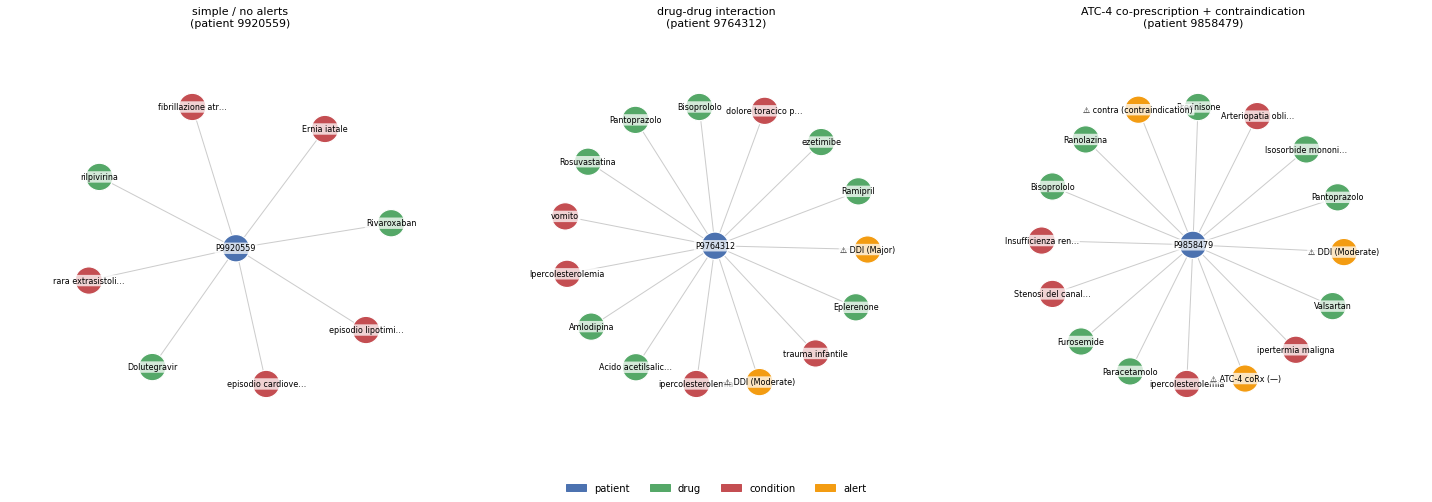

In [37]:
# ---- Visualise each demo patient's neighbourhood (networkx + matplotlib) --------------------
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

_SHORT = {"drug_drug_interaction": "DDI", "same_atc4_coprescription": "ATC-4 coRx",
          "drug_disease_contraindication": "contra"}
def _clip(s, n=18):
    s = str(s);  return s if len(s) <= n else s[:n - 1] + "…"

def patient_subgraph(oid):
    """Compact neighbourhood: cap drugs/conditions and clip long labels so the plot stays legible."""
    G = nx.DiGraph()
    G.add_node(f"P{oid}", kind="patient")
    for _, r in (graph_drugs[graph_drugs.encOid == oid]
                 .drop_duplicates("principio_attivo").head(8).iterrows()):
        n = _clip(r.principio_attivo); G.add_node(n, kind="drug"); G.add_edge(f"P{oid}", n)
    for _, r in (conditions_linked[(conditions_linked.encOid == oid) &
                 (conditions_linked.assertion == "affirmed") & (conditions_linked.experiencer == "patient")]
                 .drop_duplicates("condition").head(5).iterrows()):
        n = _clip(r.condition); G.add_node(n, kind="condition"); G.add_edge(f"P{oid}", n)
    for _, r in alerts_df[alerts_df.encOid == oid].drop_duplicates(["alert_type", "severity"]).head(4).iterrows():
        lab = f"⚠ {_SHORT.get(r.alert_type, r.alert_type)} ({r.severity})"
        G.add_node(lab, kind="alert"); G.add_edge(f"P{oid}", lab)
    return G

COLORS = {"patient": "#4C72B0", "drug": "#55A868", "condition": "#C44E52", "alert": "#F39C12"}
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (key, oid) in zip(axes, DEMO_PATIENTS.items()):
    G = patient_subgraph(oid)
    pos = nx.spring_layout(G, seed=SEED, k=2.4, iterations=300)   # more spacing + iterations = fewer overlaps
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cccccc", arrows=False, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=750, edgecolors="white", linewidths=1.2,
                           node_color=[COLORS[G.nodes[n]["kind"]] for n in G.nodes])
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))
    ax.set_title(f"{DEMO_DESC[key]}\n(patient {oid})", fontsize=11); ax.margins(0.20); ax.axis("off")
fig.legend(handles=[Patch(color=c, label=k) for k, c in COLORS.items()],
           loc="lower center", ncol=4, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

In [38]:
# ---- SPARQL queries (including a temporal one) ----------------------------------------------
PFX = "PREFIX ex:<http://example.org/clinical/> PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>"

def sparql(title, query):
    print(f"\n### {title}")
    for row in kg.query(query):
        print("   ", " | ".join(str(v) for v in row))

sparql("Q1 — patients with a Major drug-drug interaction",
       PFX + """SELECT (COUNT(DISTINCT ?p) AS ?patients) WHERE {
                  ?p ex:hasAlert ?a . ?a ex:severity "Major" . ?a ex:alertType "drug_drug_interaction" . }""")

sparql("Q2 — most frequent ATC-4 subgroups in the active discharge regimens",
       PFX + """SELECT ?atc4 (COUNT(*) AS ?n) WHERE { ?d a ex:Drug ; ex:atc4 ?atc4 . }
                GROUP BY ?atc4 ORDER BY DESC(?n) LIMIT 5""")

sparql(f"Q3 — drugs and ATC of demo patient {DEMO_PATIENTS['interaction']}",
       PFX + f"""SELECT ?ing ?atc WHERE {{ ex:patient_{DEMO_PATIENTS['interaction']} ex:takesDrug ?d .
                 ?d ex:activeIngredient ?ing ; ex:atc ?atc . }} ORDER BY ?atc""")

sparql(f"Q4 (TEMPORAL) — the patient's OWN, non-negated conditions grouped by discourse phase and explicit year",
       PFX + f"""SELECT ?phase ?year ?label WHERE {{
                   ex:patient_{DEMO_PATIENTS['both']} ex:hasMention ?m .
                   ?m rdfs:label ?label ; ex:temporalPhase ?phase ;
                      ex:assertion ?a ; ex:experiencer ?e .
                   OPTIONAL {{ ?m ex:year ?year }}
                   FILTER(?a != "negated" && ?e = "patient")
                   BIND(IF(?phase="remota",0,IF(?phase="prossima",1,2)) AS ?ord) }}
                 ORDER BY ?ord ?year LIMIT 15""")

sparql("Q5 — which active ingredient triggers the most interaction alerts?",
       PFX + """SELECT ?drug (COUNT(*) AS ?n) WHERE {
                  ?a ex:alertType "drug_drug_interaction" ; ex:involves ?drug . }
                GROUP BY ?drug ORDER BY DESC(?n) LIMIT 5""")


### Q1 — patients with a Major drug-drug interaction


    234

### Q2 — most frequent ATC-4 subgroups in the active discharge regimens


    B01AC | 600
    C07AB | 548
    A02BC | 519
    C10AA | 488
    C03CA | 367

### Q3 — drugs and ATC of demo patient 9764312
    Pantoprazolo | A02BC02
    Warfarin | B01AA03
    Acido acetilsalicilico | B01AC06
    Furosemide | C03CA01
    Eplerenone | C03DA04
    Bisoprololo | C07AB07
    Amlodipina | C08CA01
    Ramipril | C09AA05
    Rosuvastatina | C10AA07
    ezetimibe | C10AX09

### Q4 (TEMPORAL) — the patient's OWN, non-negated conditions grouped by discourse phase and explicit year
    remota | 2018 | angina
    unspecified | None | ipercolesterolemia
    unspecified | None | ipertermia maligna
    unspecified | None | Stenosi del canale vertebrale
    unspecified | None | Arteriopatia obliterante degli arti inferiori
    unspecified | None | Insufficienza renale cronica
    unspecified | None | ischemia miocardica
    unspecified | None | dispnea da sforzo
    unspecified | None | saltuari episodi di precordialgia
    unspecified | 2009 | angina instabile
    unspecified |

    Acido acetilsalicilico | 694
    Furosemide | 637
    Pantoprazolo | 592
    Dapagliflozin | 397
    Clopidogrel | 351


**Wrap-up.** The pipeline's outputs converge into one **queryable symbolic artifact**: ~149k RDF
triples linking patients, ATC-coded drugs, ICD-9-coded conditions (with a discourse-derived
`remota`/`prossima` phase and any explicit year), and provenance-carrying alerts. SPARQL answers both
cross-cohort questions (Q1, Q2, Q5) and per-patient temporal ones (Q4). The `query_graph` tool also
exposes the graph to the model, but the hand-written queries above are the dependable demonstration of
graph querying — we do not depend on the 3B model to author SPARQL. *The
temporal ordering is deliberately "rough": most conditions carry no explicit date, so the discourse
`phase` is the primary signal — a limitation revisited in Step 10.*

## Section 9 — Gold annotation and evaluation (50 patients)

We evaluate against a **single-annotator project gold set** (`data/annotations/`, seed 42, 50 patients;
every report identified by `encOid`/`reportOid` and a SHA-256 hash), built by automatic pre-annotation
followed by row-level review. The current gold provides exhaustive span-and-context annotations,
structured to support several methodological requirements:

- **Anamnesis conditions** now have an **exhaustive span-and-context gold**: *every* disease, condition,
  symptom, abnormal-finding, infection, injury and congenital-defect mention in the 50 anamneses is
  annotated (drugs, procedures, devices, normal findings and bare organisms excluded), with maximal
  non-overlapping spans and zero-based `[start, end)` offsets. This lets us measure GLiNER **recall**
  (exact-span and relaxed IoU), not just a positive rate on sampled candidates.
- **Discharge extraction is scored as a patient-level active-ingredient multiset** (duplicates counted)
  and **ingress detection uses relaxed surface alignment** by normalized mention text — our extraction
  outputs carry no offsets, so those two are *not* exact-span.
- **Context is annotated on three independent axes** — `assertion` (affirmed/negated/possible),
  `temporality` (current/historical/unspecified), `experiencer` (patient/family) — because a single
  5-way label cannot represent, e.g., *"Non familiarità per cardiopatie"* (negated **and** family).
- **ICD-9 targets allow `NIL`**: findings, organisms, drug names and vague fragments are marked
  not-codable instead of being forced onto an unrelated code.

In [39]:
# Unload the Ollama model from the GPU, and reload the spaCy + NLI models freed after Step 4.
try:
    ollama.chat(model=OLLAMA_MODEL, messages=[{"role": "user", "content": "end"}], keep_alive=0)
except Exception:
    pass
import gc, json
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score
if "kg" in globals():
    del kg; gc.collect()
if "nlp" not in globals():
    nlp = spacy.load("it_core_news_lg")
if "nli" not in globals():
    from transformers import pipeline
    nli = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=NLI_DEVICE)

# ---- load the row-by-row gold ---------------------------------------------------------------
GOLD_PATIENTS = sorted(pd.read_csv(ANNOT / "gold_report_manifest.csv").encOid.unique())
gold_dis  = pd.read_csv(ANNOT / "gold_discharge_medications_all.csv"); gold_dis["ai"] = gold_dis.active_ingredients.map(json.loads)
gold_ing  = pd.read_csv(ANNOT / "gold_ingress_medications.csv");           gold_ing["ai"] = gold_ing.active_ingredients.map(json.loads)
gold_ctx  = pd.read_csv(ANNOT / "gold_anamnesis_context.csv")
gold_icd9 = pd.read_csv(ANNOT / "gold_icd9_links.csv")
patients_by_oid = {p["encOid"]: p for p in patients}

# brand/label -> set of (salt-stripped, upper) active ingredients, for combination-aware matching
_aiconf = pd.read_parquet(EXTERNAL / "aifa" / "normalized" / "aifa_confezioni.parquet")
def _basei(n): return re.sub(r'\s+', ' ', _SALT_RE.sub('', str(n).upper())).strip()
label2ai = {}
for _den, _pa in zip(_aiconf.DENOMINAZIONE, _aiconf.PA_ASSOCIATI):
    if pd.notna(_den) and pd.notna(_pa):
        label2ai.setdefault(_basei(_den), set()).update(_basei(x) for x in str(_pa).split("/"))
def ai_of(label):
    return label2ai.get(_basei(label), {_basei(label)})

def prf(tp, fp, fn):
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return round(P, 3), round(R, 3), round(F, 3)
def _norm(x): return re.sub(r'\s+', ' ', str(x).lower().strip())

print(f"gold: {len(GOLD_PATIENTS)} patients | discharge {len(gold_dis)} mentions | "
      f"ingress {len(gold_ing)} | context {len(gold_ctx)} | icd9 {len(gold_icd9)}")

gold: 50 patients | discharge 378 mentions | ingress 304 | context 1283 | icd9 32


In [40]:
# ==== Extraction eval =========================================================================
# NB on granularity: our pipeline outputs do NOT carry character offsets, so this is *not* exact-span
# evaluation. Discharge is scored as a patient-level active-ingredient MULTISET (duplicates counted);
# ingress detection is a RELAXED surface-alignment (mentions aligned by normalized name).

# Discharge (Step 1 regex): active-ingredient multiset per patient.
tp = fp = fn = 0
for oid in GOLD_PATIENTS:
    g = Counter(_norm(i) for L in gold_dis[gold_dis.encOid == oid].ai for i in L)
    p = Counter(i.lower().strip() for L in discharge_df[discharge_df.encOid == oid].principio_attivo for i in L)
    for k in set(g) | set(p):
        tp += min(g[k], p[k]); fp += max(0, p[k] - g[k]); fn += max(0, g[k] - p[k])
dis_P, dis_R, dis_F = prf(tp, fp, fn)

# Ingress (Step 2 retrieval): detection (aligned by normalized name) + ingredient-set normalization.
det_tp = det_fp = det_fn = 0; norm_exact = norm_partial = norm_tot = 0
for oid in GOLD_PATIENTS:
    gm = gold_ing[gold_ing.encOid == oid]
    pm = ingress_drugs[(ingress_drugs.encOid == oid) & ingress_drugs.kept]
    pset = [(_norm(r.mention), ai_of(r.matched_label)) for _, r in pm.iterrows()]; used = set()
    for _, r in gm.iterrows():
        gt = _norm(r.mention_text); gai = {_basei(x) for x in r.ai}
        # align by containment only (alignment uses containment, not a loose first-word rule)
        m = next((j for j, (pt, _pa) in enumerate(pset) if j not in used and (gt in pt or pt in gt)), None)
        if m is None:
            det_fn += 1
        else:
            used.add(m); det_tp += 1; norm_tot += 1
            if pset[m][1] == gai:      norm_exact += 1       # main metric: full ingredient-set match
            elif pset[m][1] & gai:     norm_partial += 1     # at least one ingredient right (e.g. one half of a combo)
    det_fp += len(pset) - len(used)

ing_P, ing_R, ing_F = prf(det_tp, det_fp, det_fn)
_n_dis_rows = len(gold_dis); _n_dis_comp = sum(len(L) for L in gold_dis.ai)
extraction = pd.DataFrame([
    {"stage": "Step 1 discharge (regex) — active-ingredient multiset", "P": dis_P, "R": dis_R, "F1": dis_F,
     "detail": f"{_n_dis_comp} ingredient components ({_n_dis_rows} prescription rows, combos exploded)"},
    {"stage": "Step 2 ingress (retrieval) — relaxed mention detection",
     **dict(zip(["P","R","F1"], prf(det_tp, det_fp, det_fn))),
     "detail": f"ingredient-set normalization: exact {norm_exact/norm_tot:.2f}, +partial {(norm_exact+norm_partial)/norm_tot:.2f}"},
]).set_index("stage")
extraction

,P,R,F1,detail
stage,,,,
Step 1 discharge (regex) — active-ingredient multiset,1.000,0.983,0.992,"424 ingredient components (378 prescription rows, combos exploded)"
Step 2 ingress (retrieval) — relaxed mention detection,0.986,0.954,0.970,"ingredient-set normalization: exact 0.79, +partial 0.89"


Discharge extraction is essentially exact (regex over a fixed template). Ingress **detection** is
strong (the pipeline finds the drug mentions), while **normalization** — mapping a messy brand to the
right active ingredient — is the lossy part: exact ingredient-set accuracy is **0.79** among aligned
mentions (allowing partial overlap for combination products raises it to 0.89), with the residual errors being the
orthographically-similar confusions seen earlier (*Pregabalin eg → Lapatinib eg*, *Omeprazolo → Esomeprazolo*).

### GLiNER condition NER — measured against the exhaustive gold

Because the context gold now annotates **every** condition mention in the 50 anamneses, we can measure
GLiNER's **recall**, not only its precision. We score the GLiNER spans whose label is a condition type
(`malattia` / `condizione patologica`) for the 50 gold patients, on document-level character offsets
keyed by `(encOid, reportOid, start, end)`. **Exact-span P/R/F1 is the primary result**; a relaxed
**IoU ≥ 0.5** (one-to-one within a report) is reported alongside, because zero-shot NER often picks
slightly different but overlapping boundaries.

In [41]:
# ==== GLiNER condition NER: exact-span (primary) + relaxed IoU>=0.5 (secondary) ==============
_manifest = pd.read_csv(ANNOT / "gold_report_manifest.csv")
_anam_rep = dict(zip(_manifest.loc[_manifest.report_type == "Anamnesi", "encOid"],
                     _manifest.loc[_manifest.report_type == "Anamnesi", "reportOid"]))
COND_LABELS = {"malattia", "condizione patologica"}
ner_pred = anamnesis_entities[anamnesis_entities.encOid.isin(GOLD_PATIENTS) &
                              anamnesis_entities.label.isin(COND_LABELS)].copy()
ner_pred["reportOid"] = ner_pred.encOid.map(_anam_rep)

# one prediction per unique (encOid, reportOid, start, end): a span emitted under two condition
# labels (malattia / condizione patologica) must not be double-counted against a single gold span
ner_pred = ner_pred.drop_duplicates(["encOid", "reportOid", "start", "end"]).copy()

# primary: exact-span match on (encOid, reportOid, start, end), one-to-one
_gold_keys = set(zip(gold_ctx.encOid, gold_ctx.reportOid, gold_ctx.start, gold_ctx.end))
_pred_keys = list(zip(ner_pred.encOid, ner_pred.reportOid, ner_pred.start, ner_pred.end))  # unique after dedup
_pred_set  = set(_pred_keys)
ex_tp = len(_gold_keys & _pred_set)
ex_fp = len(_pred_set - _gold_keys)
ex_fn = len(_gold_keys - _pred_set)
exact_P, exact_R, exact_F = prf(ex_tp, ex_fp, ex_fn)

# secondary: relaxed IoU>=0.5, one prediction matches at most one gold span within a report
def _iou(a, b, c, d):
    inter = max(0, min(b, d) - max(a, c)); union = (b - a) + (d - c) - inter
    return inter / union if union else 0.0
rel_tp = 0
for oid in GOLD_PATIENTS:
    gp = gold_ctx.loc[gold_ctx.encOid == oid, ["start", "end"]].values.tolist()
    pp = ner_pred.loc[ner_pred.encOid == oid, ["start", "end"]].values.tolist()
    cand = sorted(((_iou(gs, ge, ps, pe), gi, pi)
                   for gi, (gs, ge) in enumerate(gp) for pi, (ps, pe) in enumerate(pp)
                   if _iou(gs, ge, ps, pe) >= 0.5), reverse=True)
    ug, up = set(), set()
    for v, gi, pi in cand:
        if gi in ug or pi in up:
            continue
        ug.add(gi); up.add(pi); rel_tp += 1
rel_fp, rel_fn = len(ner_pred) - rel_tp, len(gold_ctx) - rel_tp
rel_P, rel_R, rel_F = prf(rel_tp, rel_fp, rel_fn)

gliner_ner = pd.DataFrame([
    {"match": "exact span",        "TP": ex_tp,  "FP": ex_fp,  "FN": ex_fn,  "P": exact_P, "R": exact_R, "F1": exact_F},
    {"match": "relaxed IoU>=0.5",  "TP": rel_tp, "FP": rel_fp, "FN": rel_fn, "P": rel_P,   "R": rel_R,   "F1": rel_F},
]).set_index("match")
print(f"{len(ner_pred)} GLiNER condition predictions vs {len(gold_ctx)} exhaustive gold spans "
      f"({len(GOLD_PATIENTS)} patients)")
gliner_ner

781 GLiNER condition predictions vs 1283 exhaustive gold spans (50 patients)


,TP,FP,FN,P,R,F1
match,,,,,,
exact span,569,212,714,0.729,0.443,0.551
relaxed IoU>=0.5,638,143,645,0.817,0.497,0.618


In [42]:
# Error analysis: representative exact-span false positives and false negatives
_fp = sorted(_pred_set - _gold_keys)[:6]
_fn = sorted(_gold_keys - _pred_set)[:6]
def _fp_row(k):
    r = ner_pred[(ner_pred.encOid == k[0]) & (ner_pred.start == k[2]) & (ner_pred.end == k[3])].iloc[0]
    return {"type": "FP (spurious / boundary)", "encOid": k[0], "offsets": f"{k[2]}:{k[3]}",
            "span": r.text, "sentence": r.sentence[:55]}
def _fn_row(k):
    r = gold_ctx[(gold_ctx.encOid == k[0]) & (gold_ctx.start == k[2]) & (gold_ctx.end == k[3])].iloc[0]
    return {"type": "FN (missed by GLiNER)", "encOid": k[0], "offsets": f"{k[2]}:{k[3]}",
            "span": r.condition, "sentence": str(r.sentence)[:55]}
pd.DataFrame([_fp_row(k) for k in _fp] + [_fn_row(k) for k in _fn])

,type,encOid,offsets,span,sentence
0,FP (spurious / boundary),9920559,344:366,episodio cardiovertito,Ultimo episodio in data 22.12.2024 atriale mentre lavor
1,FP (spurious / boundary),9920559,700:731,rara extrasistolia ventricolare,rara extrasistolia ventricolare e rara extrasistolia so
2,FP (spurious / boundary),9920559,734:770,rara extrasistolia sopraventricolare,rara extrasistolia ventricolare e rara extrasistolia so
3,FP (spurious / boundary),9920559,1114:1127,TC coronarica,In data 05.11.2025 TC coronarica che documentava:
4,FP (spurious / boundary),9920559,1662:1683,fibrillazione atriale,Si ricovera per ablazione transcatetere di fibrillazion
5,FP (spurious / boundary),9992853,246:261,Colecistectomia,Colecistectomia.
6,FN (missed by GLiNER),9920559,705:731,extrasistolia ventricolare,Si segnalano: rara extrasistolia ventricolare e rara ex
7,FN (missed by GLiNER),9920559,739:770,extrasistolia sopraventricolare,Si segnalano: rara extrasistolia ventricolare e rara ex
8,FN (missed by GLiNER),9920559,1174:1234,stenosi significative delle coronarie epicardiche principali,Assenza di stenosi significative delle coronarie epicar
9,FN (missed by GLiNER),9920559,1272:1314,placca eccentrica non calcifica prossimale,Coronaria discendente anteriore con placca eccentrica n


GLiNER reaches decent **precision** but **low recall**: it misses many of the symptom / abnormal-finding
mentions the broad gold includes (e.g. `FAP`, `cardiopalmo`, `attacchi di panico`), and part of the
exact-vs-relaxed gap is boundary errors (`Non ipertensione` swallows the negation, `Alla TAC` is not a
condition). Recall is the weak point of the zero-shot NER — now *measurable* only because the
gold is exhaustive rather than a sample of GLiNER's own candidates.

The gold uses a **broad clinical-condition definition** that includes symptoms and abnormal findings,
whereas GLiNER is prompted with only two general labels (`malattia`, `condizione patologica`). The
measured recall therefore reflects **both** missed diseases **and** limited coverage of symptom/finding
expressions — a policy choice we make explicit, not a tuning failure we hide.

In [43]:
# ==== Context classification — evaluated on THREE independent axes ============================
assert gold_ctx["is_condition"].all()              # exhaustive gold: every row is a real condition mention
valid_ctx = gold_ctx.copy()
print(f"context gold: {len(valid_ctx)} condition mentions over {valid_ctx.encOid.nunique()} patients | "
      f"per-axis class counts: " + " | ".join(f"{ax} {valid_ctx[ax].value_counts().to_dict()}" for ax in
      ["assertion", "temporality", "experiencer"]))
_docs  = {oid: nlp(report_text(patients_by_oid[oid], T_ANAMNESI)) for oid in valid_ctx.encOid.unique()}
_marks = {oid: section_marks(report_text(patients_by_oid[oid], T_ANAMNESI)) for oid in valid_ctx.encOid.unique()}

# Batched NLI so the full exhaustive gold can be scored in one sweep. With multi_label=False the
# zero-shot pipeline ranks candidates by their raw *entailment* logit; we compute exactly that
# quantity in mini-batches (verified identical to classify_nli_axes) instead of one pipeline call per
# span. classify_nli_axes (Section 4c) stays the readable per-span version used in the demos.
import torch, json, hashlib
_ENT_ID = nli.model.config.label2id["entailment"]

@torch.no_grad()
def _entail_logit(premises, hypotheses, bs=32):
    out = []
    for i in range(0, len(premises), bs):
        enc = nli.tokenizer(premises[i:i + bs], hypotheses[i:i + bs], return_tensors="pt",
                            padding=True, truncation=True, max_length=256).to(nli.model.device)
        out.extend(nli.model(**enc).logits[:, _ENT_ID].tolist())
    return out

def _nli_axis_batch(items, hyp_map):
    """items: list of (sentence, condition) -> argmax-entailment key per item (matches classify_nli_axes)."""
    keys = list(hyp_map); prem, hyp = [], []
    for s, c in items:
        for k in keys:
            prem.append(s); hyp.append(hyp_map[k].format(c=c))
    lg = _entail_logit(prem, hyp); K = len(keys)
    return [keys[max(range(K), key=lambda j: lg[i * K + j])] for i in range(len(items))]

# symbolic predictions (fast) + one batched NLI pass reused by configs (b) and (c)
_rows  = list(valid_ctx.itertuples(index=False))
basic_pred = [classify_basic_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end)) for r in _rows]
dep_pred   = [classify_dep_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end))   for r in _rows]
_items = [(r.sentence, r.condition) for r in _rows]

# Cache the NLI predictions (the only slow part, ~10 min on a laptop GPU). The key hashes the gold
# spans AND the hypothesis templates, so any change to either recomputes rather than serving a stale file.
_model_id = nli.model.config._name_or_path            # cache also keyed on the NLI model
_key = hashlib.md5((_model_id + "||" + "||".join(f"{c}\t{s}" for s, c in _items) +
                    repr((ASSERT_HYP, TEMP_HYP, EXP_HYP))).encode("utf-8")).hexdigest()
_nli_cache = OUTPUTS / "step9_context_nli.json"
_cached = json.loads(_nli_cache.read_text(encoding="utf-8")) if _nli_cache.exists() else {}
if _cached.get("key") == _key:
    _na, _nt, _ne = _cached["assertion"], _cached["temporality"], _cached["experiencer"]
    print(f"loaded cached NLI context predictions ({len(_na)} spans)")
else:
    print(f"scoring {len(_items)} spans with batched NLI (one-time; cached to {_nli_cache.name} afterwards)...")
    _na = _nli_axis_batch(_items, ASSERT_HYP); _nt = _nli_axis_batch(_items, TEMP_HYP); _ne = _nli_axis_batch(_items, EXP_HYP)
    _nli_cache.write_text(json.dumps({"key": _key, "assertion": _na, "temporality": _nt, "experiencer": _ne}),
                          encoding="utf-8")

assert len(_na) == len(_items) and len(_nt) == len(_items) and len(_ne) == len(_items)
nli_pred = [{"assertion": a, "temporality": t, "experiencer": e} for a, t, e in zip(_na, _nt, _ne)]
# (c) System 1 -> System 2: keep the dep answer unless it fell back to a default, then take NLI's
sys12_pred = []
for dp, npd in zip(dep_pred, nli_pred):
    o = dict(dp)
    if o["assertion"] == "affirmed":      o["assertion"]   = npd["assertion"]
    if o["temporality"] == "unspecified": o["temporality"] = npd["temporality"]
    sys12_pred.append(o)

AXES = {"assertion": ["affirmed", "negated", "possible"],
        "temporality": ["current", "historical", "unspecified"],
        "experiencer": ["patient", "family"]}
CONFIGS = ["(a) NegEx basic", "(a) NegEx+dep", "(b) NLI", "(c) System 1+2"]
axpreds = {"(a) NegEx basic": basic_pred, "(a) NegEx+dep": dep_pred,
           "(b) NLI": nli_pred, "(c) System 1+2": sys12_pred}

from sklearn.metrics import precision_recall_fscore_support
rows = []
for cfg in CONFIGS:
    row = {"config": cfg}
    for ax, labels in AXES.items():
        yt = list(valid_ctx[ax]); yp = [p[ax] for p in axpreds[cfg]]
        P, R, F, _ = precision_recall_fscore_support(yt, yp, labels=labels, average="macro", zero_division=0)
        row[f"{ax} acc"] = round(accuracy_score(yt, yp), 2)
        row[f"{ax} mP"]  = round(P, 2)
        row[f"{ax} mR"]  = round(R, 2)
        row[f"{ax} mF1"] = round(F, 2)
    rows.append(row)
context_axes = pd.DataFrame(rows).set_index("config")
context_axes

context gold: 1283 condition mentions over 50 patients | per-axis class counts: assertion {'affirmed': 1087, 'negated': 172, 'possible': 24} | temporality {'current': 627, 'historical': 435, 'unspecified': 221} | experiencer {'patient': 1246, 'family': 37}


loaded cached NLI context predictions (1283 spans)


,assertion acc,assertion mP,assertion mR,assertion mF1,temporality acc,temporality mP,temporality mR,temporality mF1,experiencer acc,experiencer mP,experiencer mR,experiencer mF1
config,,,,,,,,,,,,
(a) NegEx basic,0.96,0.90,0.86,0.88,0.28,0.46,0.38,0.26,1.00,1.00,0.96,0.98
(a) NegEx+dep,0.89,0.74,0.73,0.69,0.31,0.46,0.41,0.30,0.98,0.99,0.65,0.72
(b) NLI,0.61,0.67,0.74,0.56,0.47,0.42,0.40,0.40,0.94,0.64,0.88,0.70
(c) System 1+2,0.62,0.65,0.80,0.57,0.46,0.44,0.41,0.38,0.98,0.99,0.65,0.72


**Reading the multi-axis table.** Each configuration predicts the three axes *directly* (the gold is
multi-axis, so the classifier must be too; a single label cannot encode "negated and family"). The
classes are imbalanced, so we read **macro-F1**, not only accuracy.

- **Assertion (affirmed / negated / possible).** Fixed-window NegEx is the strongest (acc 0.96,
  macro-F1 0.88); dependency propagation *decreases* performance (acc 0.89, macro-F1 0.69) because it
  can over-extend negation through `conj` arcs in telegraphic clinical text, so its win on the
  coordinated examples of Section 4 does not carry over. NLI performs poorly here (acc 0.61) — it
  over-predicts the rare `possible` class — so the neural model is *not* competitive on assertion.
- **Temporality (current / historical / unspecified).** The hard axis: everyone is weak. Here **NLI
  gives the best result** (acc 0.47, macro-F1 0.40), ahead of the symbolic configs (~0.30 macro-F1),
  but 0.40 is still low — telling *current* from *past* needs discourse reasoning that the section
  heuristics and a sentence-level NLI model both lack.
- **Experiencer (patient / family).** Accuracy is very high (≥ 0.94) because patient mentions dominate
  the gold; **macro-recall highlights the minority class** — the rare `family` class stays harder,
  especially for the dependency and hybrid configs (macro-F1 ≈ 0.72).

The **System-1 → System-2 hybrid** improves temporality over the dependency baseline but substantially
*lowers* assertion, and it escalates to the neural System 2 on **96%** of spans — so it delivers neither
a consistent accuracy gain nor a compute saving. The lesson (exactly why one must look past accuracy):
each syntactic or neural upgrade helps on some axes and hurts on others, and must be validated on the
axis it is meant to improve rather than assumed better.

In [44]:
# How often does the System-1→System-2 hybrid escalate an axis to the neural System 2?
def _needs_s2(r):
    a = classify_dep_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end))
    return a["assertion"] == "affirmed" or a["temporality"] == "unspecified"
n_sys2 = sum(1 for _, r in valid_ctx.iterrows() if _needs_s2(r))
print(f"System 2 (neural) consulted on {n_sys2}/{len(valid_ctx)} spans "
      f"({n_sys2/len(valid_ctx):.0%}); the rest resolved by System 1 alone.")
print("NB: the uncertainty gate (assertion=affirmed OR temporality=unspecified) is *too permissive* —\n"
      "it escalates most spans, so the hybrid does not actually save neural cost here.")

System 2 (neural) consulted on 1238/1283 spans (96%); the rest resolved by System 1 alone.
NB: the uncertainty gate (assertion=affirmed OR temporality=unspecified) is *too permissive* —
it escalates most spans, so the hybrid does not actually save neural cost here.


In [45]:
# ==== ICD-9-CM linking — raw top-1 accuracy + NIL-aware abstention ============================
# Score linking only where the gold has a code; report NIL detection separately (never force a link).
# Accuracy uses the pipeline's RAW top-1 code (icd9_code_top1, before the similarity abstention).
_pred = {}
for _, r in conditions_linked.iterrows():
    _pred.setdefault(_norm(r.condition), (r.get("icd9_code_top1"), r.icd9_sim))
gold_icd9["pipe_code"] = gold_icd9.condition.map(lambda c: (_pred.get(_norm(c)) or (None, None))[0])
gold_icd9["pipe_sim"]  = gold_icd9.condition.map(lambda c: (_pred.get(_norm(c)) or (None, None))[1])

def _norm_code(v):
    if pd.isna(v):
        return None
    return re.sub(r"\.0$", "", str(v).strip())

_code = gold_icd9[gold_icd9.gold_status == "code"].copy()
_pc = _code.pipe_code.map(_norm_code)                       # normalize BOTH sides before comparing
_gc = _code.gold_icd9_code.map(_norm_code)
exact = (_pc == _gc).mean()
categ = (_pc.map(lambda x: x.split(".")[0] if x else None) ==
         _gc.map(lambda x: x.split(".")[0] if x else None)).mean()
print(f"ICD-9 raw top-1 linking accuracy (before threshold-based abstention) on {len(_code)} codable "
      f"conditions: exact = {exact:.0%} | same 3-digit category = {categ:.0%}")

# NIL detection = similarity-threshold abstention. A missing prediction (no text join) is treated as
# abstention (similarity -> -1), i.e. a predicted NIL, rather than being silently dropped.
gold_nil = gold_icd9.gold_status != "code"
n_nil = int(gold_nil.sum())
_sim = gold_icd9.pipe_sim.fillna(-1.0)
print(f"NIL detection ({n_nil} not-codable cases) by a similarity cut-off:")
for thr in (0.86, 0.88, 0.90):
    pred_nil = _sim < thr
    tp = int((pred_nil & gold_nil).sum()); fp = int((pred_nil & ~gold_nil).sum()); fn = int((~pred_nil & gold_nil).sum())
    print(f"   sim < {thr}:  P/R/F1 = {prf(tp, fp, fn)}")
_pn = _sim < 0.88
nil088 = prf(int((_pn & gold_nil).sum()), int((_pn & ~gold_nil).sum()), int((~_pn & gold_nil).sum()))
print("=> similarity separates NIL from codable only weakly: ICD-9 linking is the pipeline's weak point.")

ICD-9 raw top-1 linking accuracy (before threshold-based abstention) on 20 codable conditions: exact = 20% | same 3-digit category = 25%
NIL detection (12 not-codable cases) by a similarity cut-off:
   sim < 0.86:  P/R/F1 = (0.75, 0.25, 0.375)
   sim < 0.88:  P/R/F1 = (0.5, 0.583, 0.538)
   sim < 0.9:  P/R/F1 = (0.407, 0.917, 0.564)
=> similarity separates NIL from codable only weakly: ICD-9 linking is the pipeline's weak point.


In [46]:
# ==== Consolidated scorecard =================================================================
PRIMARY = "(a) NegEx+dep"       # the main config, fixed before evaluation
def context_result(axis):
    r = context_axes.loc[PRIMARY]
    return (f"acc {r[f'{axis} acc']:.2f}; mP/mR/mF1 "
            f"{r[f'{axis} mP']:.2f}/{r[f'{axis} mR']:.2f}/{r[f'{axis} mF1']:.2f}")

# Step-2 figures are read from the computed table / variables, not hard-coded.
_r5 = comparison.loc["ATC-5 (substance)"]
retrieval_result = f"P/R/F1 = {_r5['Precision']:.2f}/{_r5['Recall']:.2f}/{_r5['F1']:.2f} at ATC-5 (see Section 2)"
exact_coverage = n_exact / len(discharge_linked)

scorecard = pd.DataFrame([
    ("Step 1  discharge (regex) — active-ingredient multiset",  f"P/R/F1 = {dis_P:.2f}/{dis_R:.2f}/{dis_F:.2f}"),
    ("Step 2  ingress (retrieval) — relaxed detection",     f"P/R/F1 = {ing_P:.2f}/{ing_R:.2f}/{ing_F:.2f}; norm(exact) {norm_exact/norm_tot:.2f}"),
    ("Step 2  dense retrieval vs exact-linked symbolic reference (all 857)", retrieval_result),
    ("Step 3  GLiNER condition NER — exact spans",           f"P/R/F1 = {exact_P:.2f}/{exact_R:.2f}/{exact_F:.2f}"),
    ("Step 3  GLiNER condition NER — relaxed IoU>=0.5",      f"P/R/F1 = {rel_P:.2f}/{rel_R:.2f}/{rel_F:.2f}"),
    (f"Step 4  context — assertion axis ({PRIMARY})",       context_result("assertion")),
    (f"Step 4  context — experiencer axis ({PRIMARY})",     context_result("experiencer")),
    (f"Step 4  context — temporality axis ({PRIMARY})",     context_result("temporality") + "  (hardest axis)"),
    ("Step 5  drug -> ATC linking",                         f"{exact_coverage:.0%} exact-dictionary coverage; remainder via retrieval (accuracy reflected by Step 2 norm.)"),
    ("Step 5  condition -> ICD-9 (codable rows)",           f"exact {exact:.0%} / category {categ:.0%}; NIL@0.88 P/R/F1 {nil088[0]:.2f}/{nil088[1]:.2f}/{nil088[2]:.2f} (weakest stage)"),
], columns=["stage", "result"]).set_index("stage")
with pd.option_context("display.max_colwidth", None, "display.width", 200):
    display(scorecard)

,result
stage,
Step 1 discharge (regex) — active-ingredient multiset,P/R/F1 = 1.00/0.98/0.99
Step 2 ingress (retrieval) — relaxed detection,P/R/F1 = 0.99/0.95/0.97; norm(exact) 0.79
Step 2 dense retrieval vs exact-linked symbolic reference (all 857),P/R/F1 = 0.92/0.92/0.92 at ATC-5 (see Section 2)
Step 3 GLiNER condition NER — exact spans,P/R/F1 = 0.73/0.44/0.55
Step 3 GLiNER condition NER — relaxed IoU>=0.5,P/R/F1 = 0.82/0.50/0.62
Step 4 context — assertion axis ((a) NegEx+dep),acc 0.89; mP/mR/mF1 0.74/0.73/0.69
Step 4 context — experiencer axis ((a) NegEx+dep),acc 0.98; mP/mR/mF1 0.99/0.65/0.72
Step 4 context — temporality axis ((a) NegEx+dep),acc 0.31; mP/mR/mF1 0.46/0.41/0.30 (hardest axis)
Step 5 drug -> ATC linking,95% exact-dictionary coverage; remainder via retrieval (accuracy reflected by Step 2 norm.)


**Wrap-up.** Scored as a patient-level active-ingredient multiset (discharge), relaxed surface-alignment
(ingress detection), three independent axes (context) and NIL-aware linking (ICD-9), the pipeline is strong
exactly where the signal is clean and symbolic (discharge extraction ≈ 0.99 F1; ingress *detection* ≈ 0.97;
assertion and experiencer reach high accuracy — though macro-F1 exposes weaker minority-class performance,
≈ 0.69–0.72 for the primary config), and weak where it is not: ingress **normalization** (~0.79
exact-set, brand→ingredient confusions), **temporality** (weak across every config — the best is NLI at
0.47 accuracy / 0.40 macro-F1, the open problem), and above all **condition→ICD-9 linking** (exact ~20%,
category ~25% on codable cases), where **12 of the 32 evaluated cases are not codable diagnoses at all** and
forcing a code is the wrong behaviour. The comparison of the four context configs gives a useful lesson: **the syntactic and neural upgrades help on some axes and hurt on others**, so each
must be validated on the axis it is meant to improve rather than assumed better.

*(Not attempted)* an end-to-end alert gold, which would need clinician validation beyond this project;
alerts remain traceable (Section 6) but are not claimed to be clinically complete.

## Section 10 — Discussion and limitations

This notebook prioritizes **breadth and transparency** over maximum task accuracy, mapping each stage to
a concrete course concept. A few design decisions and limitations deserve discussion.

### Which Kautz types we built — and which we did not
Across the pipeline we used a **pure symbolic** stage (regex, Step 1 — really *outside* the neuro-symbolic
taxonomy, as it has no neural part), **Type 1** (GLiNER: symbols in, symbolic spans out — Step 3), **Type 2**
(Symbolic[Neuro]: the symbolic controller that calls the NLI model, Step 4c), and **Type 6** (Neuro[Symbolic]:
the LLM tool-calling loop, Step 7). Types 3, 4 and 5 are not implemented; Type 5 is discussed explicitly
because differentiable logic was considered as an alternative to the deterministic alert engine:

- **Type 5 — Logic Tensor Networks — not implemented.** LTNs ground first-order logic into
  differentiable tensors and *learn* that grounding by maximising the satisfaction of a knowledge base
  against **labelled data**. This project has **no such supervised objective**: its clinical rules are
  fixed and deterministic, not learned from outcome labels. LTNs would therefore add machinery with
  nothing to train, so a **deterministic symbolic rule engine** (Step 6) is the right tool — it is deterministic, transparent,
  and adequate at this dataset scale. LTNs would only become attractive if we needed to *learn* soft rules from
  labelled outcome data, which we do not have.

### Techniques considered but not implemented
- **Coreference resolution** and **Semantic Role Labeling** were attractive (e.g. to tie *"il
  paziente"* / *"la stessa"* across sentences, or to attach negations to their arguments more
  robustly). We did not implement them: **no sufficiently robust free Italian** coreference or SRL model was
  selected for this project, and bootstrapping one would be fragile and essentially impossible to
  evaluate reliably on this small gold set. Dependency parsing (Step 4) already captured
  the intra-sentence syntactic scope we most needed.

### The alert engine is educational, not clinical
The DDI evidence comes from **DDInter 2.0** (a curated open-access academic DDI database) and
drug–disease contraindications from the official **MED-RT** (NLM) — no interaction pair or
contraindication table was manually authored; the rules operate over external resources. Even so, this is a **teaching artifact,
not a clinical decision-support product**: coverage is partial, the cross-lingual condition→disease
matching in Rule 3 is approximate (documented false positives), and no severity threshold has been
clinically validated. It must never be used to guide real prescribing.

The high alert rate — a large majority of the 857 patients — also signals a risk of *alert fatigue*, and
reflects the broad educational rules rather than clinically calibrated specificity.

### The weakest link, and why
Condition→**ICD-9-CM** linking (~20% exact / ~25% same-category on codable spans) is the low point. Two causes compound: ICD-9 has
16k fine-grained, formally-phrased Italian labels that a short colloquial span matches poorly, and
12 of the 32 evaluated ICD-9 cases are not codable diagnoses at all (imaging findings like *ipocinesia
laterale*, organisms, acronyms). A production system would add a **diagnosis-vs-finding filter** before
linking and retrieve top-k for clinician review rather than committing to top-1.

### The gold is a single-annotator project resource
The gold in `data/annotations/` is a **single-annotator project gold set** — automatic pre-annotation
followed by row-level review — aligned to the source text by `encOid`/`reportOid` and SHA-256. Those
hashes and offsets prove only that the annotations *match the text*, **not** that every semantic decision
(assertion, temporality, or where a symptom span ends) is beyond dispute. **No independent second
annotator or inter-annotator agreement was available**, and the context gold deliberately uses a
**broad** clinical-condition definition (symptoms and abnormal findings included). This is appropriate
for an exam project, but the numbers should be read as *project-internal*, not as a certified clinical
benchmark.

### Scaling to the full 857 (and beyond) in production
The pipeline already runs end-to-end on the full cohort for the cheap stages; the levers for a larger
deployment are exactly the ones used here, turned up:

1. **Batch + cache** the two heavy neural stages — dictionary/ICD-9 embeddings and GLiNER — to disk
   (we cache to `.npy`/`.parquet`): caching avoids recomputation on unchanged data. True incremental
   processing of only-new patients would be a production extension, not implemented here.
2. **Keep the LLM optional**: Ollama is the only *generative* component and is invoked only for individual
   demonstrations (the other neural stages are batched and cached), so it runs on **flagged / demo patients only**. At scale it should be invoked *reactively* — to
   explain an alert or arbitrate an ambiguous context — never as a batch pass over every record.
3. **Free GPU between stages** (as we do for GLiNER) so a 4 GB card can host the whole pipeline; a
   larger card would simply let the stages stay resident.
4. Swap the in-memory `rdflib` graph for a real **triple store** (e.g. GraphDB/Blazegraph) once the
   graph outgrows RAM, keeping the same SPARQL interface.

### Closing
The value of this project is not any single metric but the **end-to-end neuro-symbolic story**: text →
symbolic structure (regex) → dense retrieval → zero-shot neural spans → syntax-aware symbolic context
→ ontology linking → deterministic reasoning → LLM tool-calling → a queryable knowledge graph, with
every stage named against the course's conceptual map and evaluated against a gold set.